# Bank Stress Monitor — Phase 3
## Historical Model Training, Scoring & Validation

**Author:** Juhi Shah  
**Date:** March 2026  
**Data Source:** FDIC Public API (banks.data.fdic.gov)  
**Training Period:** 2003 Q1 — 2023 Q4 (587,294 observations)  
**Scoring Period:** 2025 Q4 (4,303 active banks)  

---

### Notebook Structure
| Section | Cells | Description |
|---------|-------|-------------|
| Setup & Data Pull | 1-6 | Imports, helper functions, FDIC API pull |
| Model Training | 7-11 | Logistic regression, weight derivation |
| Scoring & Validation | 12-16 | Stress scores, backtest, AUC/CAP/KS |
| SVB Deep Dive | 17-19 | Why SVB scored only 55/100 |
| Output Generation | 20, 29 | CSVs, SQLite database |
| Visualizations | 21-28 | 6 publication-ready charts |

---

### Key Results
- **Historical Score AUC:** 0.947 (2010-2013), 0.879 (2007-2009)
- **CAP Curve:** Top 10% of flagged banks captures 66% of crisis failures
- **Current Watchlist:** 127 Deeply Stressed, 24 Emerging Risk banks
- **Model trained on:** 4,491 historical FDIC failures (2003-2023)

In [2]:
# ============================================================
# BANK STRESS MONITOR
# Phase 3 — Historical Data Pull & Model Building
# ============================================================
# Author:      Juhi Shah
# Date:        March 2026
# Data Source: FDIC BankFind Suite Public API
#
# OVERVIEW:
#   Pulls 85 quarters of historical FDIC call report data
#   (2002 Q4 → 2023 Q4) for all US banks, calculates 10
#   stress ratios + 10 QoQ trend variables, assigns default
#   labels using FDIC failures list, trains logistic
#   regression to derive data-driven weights, and produces
#   two stress scores for all 4,303 active banks:
#
#   1. Historical Score — regression-derived weights + 5% floor
#   2. Current Regime Score — equal weights (10% each)
#
# MODEL SPECIFICATION:
#   Features:      20 (10 ratios + 10 QoQ trends)
#   Default window: 2 years forward
#   Class weight:  balanced (~31x for failures)
#   Weight floor:  5% minimum per ratio
#   Training:      2003 Q1 → 2023 Q4
#   Validation:    2024 Q1 → 2025 Q4 (out-of-sample)
#
# KEY DECISIONS DOCUMENTED:
#   - Securities ratio retained despite low historical weight
#     (SVB-type risk captured in Current Regime Score)
#   - No geographic indicators (addressed in visualization)
#   - Logistic regression chosen for interpretability
#   - 5% weight floor prevents ratio elimination
#   - Post-failure observations excluded from training
# ============================================================

import pandas as pd
import numpy as np
import requests
import time
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ── CONSTANTS ───────────────────────────────────────────────

# 20 raw fields — same as Phase 2, validated historically
FIELDS = [
    "CERT", "REPDTE",
    "ASSET", "DEP", "DEPUNINS", "LNLSGR", "SC",
    "EQTOT", "INTAN", "CHBAL", "OTHBRF",
    "RBCT1J", "RBCT2",
    "LNATRES", "NAASSET", "P9ASSET", "ORE",
    "LNRECONS", "LNRENRES",
    "NETINC", "NIM",
]

# 10 stress ratios
RATIO_COLS = [
    'LEVERAGE_RATIO', 'TEXAS_RATIO', 'SECURITIES_RATIO',
    'UNINSURED_DEP_RATIO', 'ROA', 'LTD_RATIO', 'CRE_RATIO',
    'NIM_RATIO', 'CASH_RATIO', 'BORROW_RATIO'
]

# 10 trend variables
TREND_COLS = [f"{r}_TREND" for r in RATIO_COLS]

# Stress direction — used for capping
STRESS_DIRECTION = {
    'LEVERAGE_RATIO':      'LOW',
    'TEXAS_RATIO':         'HIGH',
    'SECURITIES_RATIO':    'HIGH',
    'UNINSURED_DEP_RATIO': 'HIGH',
    'ROA':                 'LOW',
    'LTD_RATIO':           'HIGH',
    'CRE_RATIO':           'HIGH',
    'NIM_RATIO':           'LOW',
    'CASH_RATIO':          'LOW',
    'BORROW_RATIO':        'HIGH',
}

# Weight floor — minimum weight per ratio
WEIGHT_FLOOR = 0.05  # 5%

# Default window
DEFAULT_WINDOW_YEARS = 2

# Training period
TRAIN_START = '2003-01-01'
TRAIN_END   = '2023-12-31'

# Out-of-sample validation period
OOS_START = '2024-01-01'
OOS_END   = '2025-12-31'

print("Libraries imported successfully")
print(f"\nModel specification:")
print(f"  Features:        {len(RATIO_COLS)} ratios + "
      f"{len(TREND_COLS)} trends = {len(RATIO_COLS)+len(TREND_COLS)} total")
print(f"  Default window:  {DEFAULT_WINDOW_YEARS} years")
print(f"  Weight floor:    {WEIGHT_FLOOR*100:.0f}%")
print(f"  Training period: {TRAIN_START} → {TRAIN_END}")
print(f"  Validation:      {OOS_START} → {OOS_END}")

Libraries imported successfully

Model specification:
  Features:        10 ratios + 10 trends = 20 total
  Default window:  2 years
  Weight floor:    5%
  Training period: 2003-01-01 → 2023-12-31
  Validation:      2024-01-01 → 2025-12-31


In [3]:
# ============================================================
# CELL 2: HELPER FUNCTIONS
# ============================================================
# Purpose: Define all reusable functions used throughout
#          the pipeline — pull, clean, calculate, label
#          Centralizing here ensures consistency across
#          all quarters and makes the pipeline readable
# ============================================================

def generate_quarter_dates(start_year, start_q,
                            end_year, end_q):
    """
    Generate list of quarter end dates in YYYYMMDD format
    Example: generate_quarter_dates(2002, 4, 2003, 2)
             → ['20021231', '20030331', '20030630']
    """
    quarter_ends = {
        1: '0331', 2: '0630',
        3: '0930', 4: '1231'
    }
    dates = []
    year, q = start_year, start_q
    while (year < end_year) or (
            year == end_year and q <= end_q):
        dates.append(f"{year}{quarter_ends[q]}")
        q += 1
        if q > 4:
            q = 1
            year += 1
    return dates


def pull_quarter(quarter_date, fields,
                  url="https://banks.data.fdic.gov/api/financials"):
    """
    Pull financial data for one quarter from FDIC API
    Handles pagination — returns all banks for that quarter
    """
    params = {
        "fields": ",".join(fields),
        "filters": f"REPDTE:{quarter_date}",
        "limit": 10000,
        "offset": 0,
        "output": "json"
    }
    response = requests.get(url, params=params)
    data = response.json()
    df = pd.DataFrame(
        [item["data"] for item in data["data"]]
    )

    # Convert numeric fields
    for col in [f for f in fields
                if f not in ['CERT', 'REPDTE']]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Convert CERT to int
    df['CERT'] = pd.to_numeric(
        df['CERT'], errors='coerce'
    ).astype('Int64')

    return df


def assign_size_tier(asset):
    """Assign size tier based on total assets ($thousands)"""
    if pd.isna(asset):
        return 'Unknown'
    elif asset < 1_000_000:
        return 'Community'
    elif asset < 10_000_000:
        return 'Mid-Size'
    elif asset < 100_000_000:
        return 'Large Regional'
    else:
        return 'Large'


def calculate_ratios(df):
    """
    Calculate all 10 stress ratios from raw FDIC fields
    Identical logic to Phase 2 — ensures consistency
    Returns dataframe with ratio columns added
    """
    d = df.copy()

    # Fill missing values conservatively
    for col in ['INTAN', 'RBCT2', 'P9ASSET',
                'ORE', 'OTHBRF']:
        d[col] = d[col].fillna(0)

    # Intermediate calculations
    d['NPA']       = d['NAASSET'] + d['P9ASSET'] + d['ORE']
    d['TCE']       = d['EQTOT'] - d['INTAN']
    d['TOTAL_CAP'] = d['RBCT1J'] + d['RBCT2']
    d['CRE_LOANS'] = d['LNRECONS'] + d['LNRENRES']

    # 10 Stress Ratios
    d['LEVERAGE_RATIO']      = d['RBCT1J'] / d['ASSET']
    d['TEXAS_RATIO']         = (d['NPA'] /
                                 (d['TCE'] + d['LNATRES']))
    d['SECURITIES_RATIO']    = d['SC'] / d['ASSET']
    d['UNINSURED_DEP_RATIO'] = d['DEPUNINS'] / d['DEP']
    d['ROA']                 = d['NETINC'] / d['ASSET']
    d['LTD_RATIO']           = d['LNLSGR'] / d['DEP']
    d['CRE_RATIO']           = d['CRE_LOANS'] / d['TOTAL_CAP']
    d['NIM_RATIO']           = d['NIM'] / d['ASSET']
    d['CASH_RATIO']          = d['CHBAL'] / d['ASSET']
    d['BORROW_RATIO']        = d['OTHBRF'] / d['ASSET']

    # Replace infinities with NaN
    for col in RATIO_COLS:
        d[col] = d[col].replace([np.inf, -np.inf], np.nan)

    # Flag negative TCE
    d['NEGATIVE_TCE'] = d['TCE'] < 0

    # Size tier
    d['SIZE_TIER'] = d['ASSET'].apply(assign_size_tier)

    return d


def apply_one_sided_caps(df, ratio_cols,
                          stress_direction, percentile=0.99):
    """
    Apply one-sided outlier capping per size tier
    HIGH stress ratios: cap bottom tail only (1st percentile)
    LOW stress ratios:  cap top tail only (99th percentile)
    Preserves extreme stress signals — only removes
    impossible values on the non-stress side
    """
    d = df.copy()
    tier_order = ['Community', 'Mid-Size',
                  'Large Regional', 'Large']

    for col in ratio_cols:
        direction = stress_direction[col]
        for tier in tier_order:
            mask = d['SIZE_TIER'] == tier
            tier_data = d.loc[mask, col].dropna()

            if direction == 'HIGH':
                # Cap bottom only — preserve high stress
                p01 = tier_data.quantile(1 - percentile)
                d.loc[mask, col] = d.loc[
                    mask, col].clip(lower=p01)
            else:
                # Cap top only — preserve low stress
                p99 = tier_data.quantile(percentile)
                d.loc[mask, col] = d.loc[
                    mask, col].clip(upper=p99)
    return d


def assign_default_labels(df, quarter_date,
                           failures_df,
                           window_years=2):
    """
    Assign default labels to bank-quarter observations

    Rules:
      DEFAULT = 1 if bank failed within window_years
                of quarter_date
      POST_FAILURE = True if bank already failed before
                     quarter_date — exclude from training
    """
    d = df.copy()
    window_end = (quarter_date +
                  pd.DateOffset(years=window_years))

    # Merge failure dates
    d = d.merge(
        failures_df[['CERT', 'FAILDATE']],
        on='CERT', how='left'
    )

    # Default = 1 if failed within window
    d['DEFAULT'] = (
        (d['FAILDATE'] >= quarter_date) &
        (d['FAILDATE'] <= window_end)
    ).astype(int)

    # Post-failure flag — exclude these observations
    d['POST_FAILURE'] = (
        d['FAILDATE'] < quarter_date
    ).fillna(False)

    # Drop FAILDATE — keep only flags
    d = d.drop(columns=['FAILDATE'])

    return d


def calculate_data_completeness(df, ratio_cols):
    """Calculate % of ratios available per bank"""
    df['RATIOS_AVAILABLE'] = (
        df[ratio_cols].notna().sum(axis=1)
    )
    df['DATA_COMPLETENESS'] = (
        df['RATIOS_AVAILABLE'] / len(ratio_cols) * 100
    )
    return df


print("All helper functions defined successfully")
print(f"\nFunctions available:")
funcs = [
    'generate_quarter_dates',
    'pull_quarter',
    'assign_size_tier',
    'calculate_ratios',
    'apply_one_sided_caps',
    'assign_default_labels',
    'calculate_data_completeness'
]
for f in funcs:
    print(f"  ✅ {f}()")

All helper functions defined successfully

Functions available:
  ✅ generate_quarter_dates()
  ✅ pull_quarter()
  ✅ assign_size_tier()
  ✅ calculate_ratios()
  ✅ apply_one_sided_caps()
  ✅ assign_default_labels()
  ✅ calculate_data_completeness()


In [4]:
# ============================================================
# CELL 3: PULL FDIC FAILURES LIST
# ============================================================
# Purpose: Get complete list of US bank failures
#          This is our default label source
#          Validated in Phase 3 sample notebook
#
# Key findings from sample validation:
#   - 569 failures from 2003 onwards
#   - Peak: 148 in 2009, 157 in 2010
#   - SVB, Signature, First Republic in 2023
#   - Date format: M/D/YYYY (not YYYY-MM-DD)
#   - Some very old failures have no CERT — excluded
# ============================================================

url_failures = "https://banks.data.fdic.gov/api/failures"

params_failures = {
    "fields": "CERT,NAME,FAILDATE,SAVR,RESTYPE",
    "limit": 10000,
    "offset": 0,
    "output": "json"
}

response_failures = requests.get(
    url_failures, params=params_failures
)
data_failures = response_failures.json()
failures_df = pd.DataFrame(
    [item["data"] for item in data_failures["data"]]
)

# Convert FAILDATE — format is M/D/YYYY
failures_df['FAILDATE'] = pd.to_datetime(
    failures_df['FAILDATE'],
    format='%m/%d/%Y',
    errors='coerce'
)

# Convert CERT to numeric — drop rows with no CERT
failures_df['CERT'] = pd.to_numeric(
    failures_df['CERT'], errors='coerce'
)
failures_df = failures_df.dropna(subset=['CERT'])
failures_df['CERT'] = failures_df['CERT'].astype(int)

# Study period failures
failures_study = failures_df[
    failures_df['FAILDATE'] >= '2003-01-01'
].copy()
failures_study['FAIL_YEAR'] = (
    failures_study['FAILDATE'].dt.year
)

print(f"Total failures in FDIC database: {len(failures_df):,}")
print(f"Failures from 2003 onwards:      "
      f"{len(failures_study):,}")
print(f"\nFailures by year:")
year_counts = (failures_study['FAIL_YEAR']
               .value_counts()
               .sort_index())
for year, count in year_counts.items():
    bar = '█' * (count // 5)
    print(f"  {year}: {count:>4}  {bar}")

Total failures in FDIC database: 3,626
Failures from 2003 onwards:      569

Failures by year:
  2003:    3  
  2004:    4  
  2007:    3  
  2008:   30  ██████
  2009:  148  █████████████████████████████
  2010:  157  ███████████████████████████████
  2011:   92  ██████████████████
  2012:   51  ██████████
  2013:   24  ████
  2014:   18  ███
  2015:    8  █
  2016:    5  █
  2017:    8  █
  2019:    4  
  2020:    4  
  2023:    5  █
  2024:    2  
  2025:    2  
  2026:    1  


In [5]:
# ============================================================
# CELL 4: GENERATE QUARTER DATES
# ============================================================
# Purpose: Generate all quarter end dates for the full
#          historical pull
#
# Date range:
#   2002 Q4 (20021231) — baseline for trend calculation
#   2003 Q1 (20030331) — first training quarter
#   ...
#   2023 Q4 (20231231) — last training quarter
#
# Total: 85 quarters (1 baseline + 84 training)
#
# Note: 2002 Q4 is pulled but NOT included in training data
#       It serves only as the previous quarter for
#       calculating Q1 2003 trend variables
# ============================================================

# Generate all quarters from 2002 Q4 to 2023 Q4
all_quarter_dates = generate_quarter_dates(
    2002, 4, 2023, 4
)

# Separate baseline from training quarters
baseline_quarter = all_quarter_dates[0]
training_quarters = all_quarter_dates[1:]

print(f"Total quarters generated: {len(all_quarter_dates)}")
print(f"Baseline quarter:         {baseline_quarter}")
print(f"First training quarter:   {training_quarters[0]}")
print(f"Last training quarter:    {training_quarters[-1]}")
print(f"Total training quarters:  {len(training_quarters)}")

print(f"\nFull quarter list (first 8 and last 8):")
print("  First 8:")
for q in all_quarter_dates[:8]:
    print(f"    {q}")
print("  ...")
print("  Last 8:")
for q in all_quarter_dates[-8:]:
    print(f"    {q}")

# Estimate runtime
est_seconds = len(all_quarter_dates) * 5
est_minutes = est_seconds / 60
print(f"\nEstimated runtime @ 5s/quarter: "
      f"{est_minutes:.0f} minutes")

Total quarters generated: 85
Baseline quarter:         20021231
First training quarter:   20030331
Last training quarter:    20231231
Total training quarters:  84

Full quarter list (first 8 and last 8):
  First 8:
    20021231
    20030331
    20030630
    20030930
    20031231
    20040331
    20040630
    20040930
  ...
  Last 8:
    20220331
    20220630
    20220930
    20221231
    20230331
    20230630
    20230930
    20231231

Estimated runtime @ 5s/quarter: 7 minutes


In [6]:
# ============================================================
# CELL 5: FULL HISTORICAL DATA PULL
# ============================================================
# Purpose: Pull financial data for all 85 quarters
#          Apply cleaning and ratio calculation per quarter
#          Calculate QoQ trend variables
#          Assign default labels
#          Remove post-failure observations
#
# Pipeline per quarter:
#   1. Pull raw data from FDIC API
#   2. Calculate ratios
#   3. Apply one-sided outlier capping
#   4. Calculate QoQ trends vs previous quarter
#   5. Assign default labels (2-year window)
#   6. Remove post-failure observations
#   7. Calculate data completeness
#   8. Append to master dataset
#
# Note: Baseline quarter (2002 Q4) is processed but
#       not appended — used only for trend calculation
# ============================================================

all_data = []           # Master list for all quarters
prev_quarter_ratios = None  # For trend calculation
errors = []             # Track any API errors

print("=" * 65)
print("FULL HISTORICAL DATA PULL")
print(f"Processing {len(all_quarter_dates)} quarters...")
print("=" * 65)

total_start = time.time()

for i, quarter in enumerate(all_quarter_dates):

    quarter_start = time.time()
    is_baseline = (quarter == baseline_quarter)

    try:
        # ── Step 1: Pull raw data ──────────────────────────
        df = pull_quarter(quarter, FIELDS)

        if len(df) == 0:
            print(f"  {quarter}: No data returned — skipping")
            continue

        # ── Step 2: Calculate ratios ───────────────────────
        df = calculate_ratios(df)

        # ── Step 3: One-sided outlier capping ──────────────
        df = apply_one_sided_caps(
            df, RATIO_COLS, STRESS_DIRECTION
        )

        # ── Step 4: Calculate QoQ trends ──────────────────
        if prev_quarter_ratios is not None:
            prev_renamed = prev_quarter_ratios.rename(
                columns={
                    col: f"{col}_PREV"
                    for col in RATIO_COLS
                }
            )
            df = df.merge(
                prev_renamed, on='CERT', how='left'
            )
            for col in RATIO_COLS:
                df[f"{col}_TREND"] = (
                    df[col] - df[f"{col}_PREV"]
                )
            df = df.drop(
                columns=[f"{col}_PREV"
                         for col in RATIO_COLS]
            )
        else:
            for col in RATIO_COLS:
                df[f"{col}_TREND"] = np.nan

        # ── Step 5: Save ratios for next quarter ───────────
        prev_quarter_ratios = df[
            ['CERT'] + RATIO_COLS
        ].copy()

        # ── Skip remaining steps for baseline ─────────────
        if is_baseline:
            elapsed = time.time() - quarter_start
            print(f"  {quarter} [BASELINE]: "
                  f"{len(df):,} banks | {elapsed:.1f}s")
            continue

        # ── Step 6: Assign default labels ─────────────────
        quarter_date = pd.Timestamp(
            f"{quarter[:4]}-{quarter[4:6]}-{quarter[6:]}"
        )
        df = assign_default_labels(
            df, quarter_date, failures_df,
            window_years=DEFAULT_WINDOW_YEARS
        )

        # ── Step 7: Remove post-failure observations ───────
        post_failure_count = df['POST_FAILURE'].sum()
        df = df[~df['POST_FAILURE']].drop(
            columns=['POST_FAILURE']
        )

        # ── Step 8: Data completeness ──────────────────────
        df = calculate_data_completeness(df, RATIO_COLS)

        # ── Step 9: Append to master dataset ───────────────
        all_data.append(df)

        # ── Progress report ────────────────────────────────
        elapsed = time.time() - quarter_start
        defaults = int(df['DEFAULT'].sum())
        trends_ok = df['LEVERAGE_RATIO_TREND'].notna().sum()

        # Print every quarter but summarize cleanly
        if i % 4 == 1 or i < 5 or i >= len(all_quarter_dates) - 4:
            print(f"  {quarter}: {len(df):,} banks | "
                  f"defaults: {defaults:>4} | "
                  f"excl: {post_failure_count:>3} | "
                  f"trends: {trends_ok:,} | "
                  f"{elapsed:.1f}s")
        elif i % 4 == 0:
            print(f"  ... {quarter[:4]} processed")

    except Exception as e:
        errors.append({'quarter': quarter, 'error': str(e)})
        print(f"  {quarter}: ERROR — {str(e)}")
        continue

# ── Combine all quarters ───────────────────────────────────
total_elapsed = time.time() - total_start
historical_df = pd.concat(all_data, ignore_index=True)

print("\n" + "=" * 65)
print("PULL COMPLETE")
print("=" * 65)
print(f"Total time:          {total_elapsed/60:.1f} minutes")
print(f"Total rows:          {len(historical_df):,}")
print(f"Total columns:       {len(historical_df.columns)}")
print(f"Quarters processed:  {len(all_data)}")
print(f"API errors:          {len(errors)}")

if errors:
    print("\nErrors encountered:")
    for e in errors:
        print(f"  {e['quarter']}: {e['error']}")

print(f"\nMemory usage: "
      f"{historical_df.memory_usage(deep=True).sum()/1024**2:.0f} MB")

FULL HISTORICAL DATA PULL
Processing 85 quarters...
  20021231 [BASELINE]: 9,465 banks | 5.2s
  20030331: 9,414 banks | defaults:    6 | excl:  13 | trends: 9,363 | 4.9s
  20030630: 9,369 banks | defaults:    5 | excl:  13 | trends: 9,319 | 5.1s
  20030930: 9,338 banks | defaults:    5 | excl:  13 | trends: 9,283 | 5.1s
  20031231: 9,286 banks | defaults:    4 | excl:  13 | trends: 9,223 | 5.3s
  20040331: 9,219 banks | defaults:    1 | excl:  13 | trends: 9,170 | 9.3s
  ... 2004 processed
  20050331: 9,032 banks | defaults:    1 | excl:  11 | trends: 8,977 | 5.0s
  ... 2005 processed
  20060331: 8,886 banks | defaults:    5 | excl:  11 | trends: 8,822 | 4.8s
  ... 2006 processed
  20070331: 8,743 banks | defaults:   61 | excl:  10 | trends: 8,684 | 4.6s
  ... 2007 processed
  20080331: 8,582 banks | defaults:  217 | excl:   8 | trends: 8,525 | 5.2s
  ... 2008 processed
  20090331: 8,318 banks | defaults:  302 | excl:  21 | trends: 8,286 | 4.8s
  ... 2009 processed
  20100331: 8,008 ba

In [7]:
# ============================================================
# CELL 6: HISTORICAL DATA QUALITY DIAGNOSTIC
# ============================================================
# Purpose: Validate the full historical dataset before
#          model building
#          Key checks:
#          1. Row and column counts
#          2. Date range coverage
#          3. Default label distribution
#          4. Data completeness
#          5. Ratio distributions across periods
#          6. Class imbalance confirmation
# ============================================================

print("=" * 65)
print("HISTORICAL DATASET QUALITY DIAGNOSTIC")
print("=" * 65)

# ── 1. Basic counts ────────────────────────────────────────
print(f"\n1. BASIC COUNTS")
print(f"   Total rows:          {len(historical_df):,}")
print(f"   Total columns:       {len(historical_df.columns)}")
print(f"   Unique banks:        "
      f"{historical_df['CERT'].nunique():,}")
print(f"   Unique quarters:     "
      f"{historical_df['REPDTE'].nunique()}")

# ── 2. Date range ──────────────────────────────────────────
print(f"\n2. DATE RANGE")
print(f"   First quarter: {historical_df['REPDTE'].min()}")
print(f"   Last quarter:  {historical_df['REPDTE'].max()}")

# ── 3. Default distribution ────────────────────────────────
print(f"\n3. DEFAULT LABEL DISTRIBUTION")
total = len(historical_df)
defaults = historical_df['DEFAULT'].sum()
healthy = total - defaults
print(f"   Default = 1:  {defaults:,} ({100*defaults/total:.2f}%)")
print(f"   Default = 0:  {healthy:,} ({100*healthy/total:.2f}%)")
print(f"   Imbalance:    1:{healthy/defaults:.0f}")

# ── 4. Data completeness ───────────────────────────────────
print(f"\n4. DATA COMPLETENESS")
high = (historical_df['DATA_COMPLETENESS'] >= 80).sum()
med  = ((historical_df['DATA_COMPLETENESS'] >= 60) &
        (historical_df['DATA_COMPLETENESS'] < 80)).sum()
low  = (historical_df['DATA_COMPLETENESS'] < 60).sum()
print(f"   High (>=80%): {high:,} ({100*high/total:.1f}%)")
print(f"   Medium:       {med:,} ({100*med/total:.1f}%)")
print(f"   Low (<60%):   {low:,} ({100*low/total:.1f}%)")

# ── 5. Negative TCE banks ──────────────────────────────────
print(f"\n5. NEGATIVE TCE FLAGS")
neg_tce = historical_df['NEGATIVE_TCE'].sum()
print(f"   Negative TCE observations: {neg_tce:,} "
      f"({100*neg_tce/total:.2f}%)")

# ── 6. Size tier distribution ──────────────────────────────
print(f"\n6. SIZE TIER DISTRIBUTION")
tier_counts = historical_df['SIZE_TIER'].value_counts()
for tier in ['Community', 'Mid-Size',
             'Large Regional', 'Large']:
    count = tier_counts.get(tier, 0)
    pct = 100 * count / total
    print(f"   {tier:<20}: {count:>8,} ({pct:.1f}%)")

# ── 7. Ratio coverage ──────────────────────────────────────
print(f"\n7. RATIO COVERAGE (% valid non-null)")
print(f"   {'Ratio':<25} {'Coverage':>10}")
print(f"   {'-'*38}")
for col in RATIO_COLS:
    valid = historical_df[col].notna().sum()
    pct = 100 * valid / total
    print(f"   {col:<25} {pct:>9.1f}%")

# ── 8. Default rate by year ────────────────────────────────
print(f"\n8. DEFAULT RATE BY YEAR")
historical_df['YEAR'] = historical_df['REPDTE'].astype(
    str).str[:4].astype(int)
year_stats = historical_df.groupby('YEAR').agg(
    total=('DEFAULT', 'count'),
    defaults=('DEFAULT', 'sum')
).reset_index()
year_stats['rate'] = (100 * year_stats['defaults'] /
                      year_stats['total'])
print(f"   {'Year':>6} {'Banks':>8} "
      f"{'Defaults':>10} {'Rate':>8}")
print(f"   {'-'*36}")
for _, row in year_stats.iterrows():
    print(f"   {row['YEAR']:>6} {row['total']:>8,} "
          f"{row['defaults']:>10,.0f} "
          f"{row['rate']:>7.2f}%")

print("\n" + "=" * 65)
print("DIAGNOSTIC COMPLETE")
print("=" * 65)

HISTORICAL DATASET QUALITY DIAGNOSTIC

1. BASIC COUNTS
   Total rows:          587,294
   Total columns:       51
   Unique banks:        10,448
   Unique quarters:     84

2. DATE RANGE
   First quarter: 20030331
   Last quarter:  20231231

3. DEFAULT LABEL DISTRIBUTION
   Default = 1:  4,491 (0.76%)
   Default = 0:  582,803 (99.24%)
   Imbalance:    1:130

4. DATA COMPLETENESS
   High (>=80%): 585,794 (99.7%)
   Medium:       1 (0.0%)
   Low (<60%):   1,499 (0.3%)

5. NEGATIVE TCE FLAGS
   Negative TCE observations: 387 (0.07%)

6. SIZE TIER DISTRIBUTION
   Community           :  525,262 (89.4%)
   Mid-Size            :   51,805 (8.8%)
   Large Regional      :    8,491 (1.4%)
   Large               :    1,736 (0.3%)

7. RATIO COVERAGE (% valid non-null)
   Ratio                       Coverage
   --------------------------------------
   LEVERAGE_RATIO                 99.7%
   TEXAS_RATIO                    99.7%
   SECURITIES_RATIO              100.0%
   UNINSURED_DEP_RATIO          

In [8]:
# ============================================================
# CELL 8: PREPARE TRAINING DATA
# ============================================================
# Purpose: Prepare features and target for logistic
#          regression
#
# Steps:
#   1. Filter to training period (2003-2023)
#   2. Select features (20: 10 ratios + 10 trends)
#   3. Handle remaining missing values
#   4. Standardize features (mean=0, std=1)
#   5. Confirm class distribution
#
# Note: We use ALL 20 features for regression
#       But extract ONLY 10 ratio coefficients for weights
#       Trend coefficients improve weight accuracy but
#       are not used directly in the composite score
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ── Step 1: Filter to training period ─────────────────────
train_df = historical_df[
    (historical_df['REPDTE'] >= '20030101') &
    (historical_df['REPDTE'] <= '20231231')
].copy()

print(f"Training observations: {len(train_df):,}")

# ── Step 2: Define features ────────────────────────────────
feature_cols = RATIO_COLS + TREND_COLS
target_col = 'DEFAULT'

print(f"Features: {len(feature_cols)} "
      f"({len(RATIO_COLS)} ratios + {len(TREND_COLS)} trends)")

# ── Step 3: Handle missing values ─────────────────────────
# Drop rows where target is missing
train_df = train_df.dropna(subset=[target_col])

# For features — impute with median per size tier
# Missing features are rare (< 1%) but regression
# cannot handle NaN values
print(f"\nMissing values per feature (before imputation):")
missing = train_df[feature_cols].isna().sum()
missing_pct = 100 * missing / len(train_df)
for col in feature_cols:
    if missing[col] > 0:
        print(f"  {col:<30}: {missing[col]:,} "
              f"({missing_pct[col]:.2f}%)")

# Impute with median per size tier
for col in feature_cols:
    if train_df[col].isna().sum() > 0:
        for tier in ['Community', 'Mid-Size',
                     'Large Regional', 'Large']:
            mask = train_df['SIZE_TIER'] == tier
            tier_median = train_df.loc[mask, col].median()
            train_df.loc[
                mask & train_df[col].isna(), col
            ] = tier_median

# Verify no missing values remain
remaining_missing = train_df[feature_cols].isna().sum().sum()
print(f"\nMissing values after imputation: {remaining_missing}")

# ── Step 4: Extract features and target ───────────────────
X = train_df[feature_cols].values
y = train_df[target_col].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"Class distribution:")
print(f"  Default=0: {(y==0).sum():,} ({100*(y==0).mean():.2f}%)")
print(f"  Default=1: {(y==1).sum():,} ({100*(y==1).mean():.2f}%)")

# ── Step 5: Standardize features ──────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nStandardization complete")
print(f"  Feature means (should be ~0): "
      f"min={X_scaled.mean(axis=0).min():.4f} "
      f"max={X_scaled.mean(axis=0).max():.4f}")
print(f"  Feature stds (should be ~1):  "
      f"min={X_scaled.std(axis=0).min():.4f} "
      f"max={X_scaled.std(axis=0).max():.4f}")

Training observations: 587,294
Features: 20 (10 ratios + 10 trends)

Missing values per feature (before imputation):
  LEVERAGE_RATIO                : 1,499 (0.26%)
  TEXAS_RATIO                   : 1,501 (0.26%)
  UNINSURED_DEP_RATIO           : 5,686 (0.97%)
  ROA                           : 1,499 (0.26%)
  LTD_RATIO                     : 5,685 (0.97%)
  CRE_RATIO                     : 1,505 (0.26%)
  NIM_RATIO                     : 1,499 (0.26%)
  LEVERAGE_RATIO_TREND          : 2,562 (0.44%)
  TEXAS_RATIO_TREND             : 2,565 (0.44%)
  SECURITIES_RATIO_TREND        : 1,063 (0.18%)
  UNINSURED_DEP_RATIO_TREND     : 6,721 (1.14%)
  ROA_TREND                     : 2,562 (0.44%)
  LTD_RATIO_TREND               : 6,719 (1.14%)
  CRE_RATIO_TREND               : 2,570 (0.44%)
  NIM_RATIO_TREND               : 2,562 (0.44%)
  CASH_RATIO_TREND              : 1,063 (0.18%)
  BORROW_RATIO_TREND            : 1,063 (0.18%)

Missing values after imputation: 0

Feature matrix shape: (587294,

In [9]:
import os
import json
import time

historical_df = pd.read_csv(
    'bank_stress_historical_2003_2023.csv'
)
historical_df['REPDTE'] = historical_df['REPDTE'].astype(str)

print(f"Loaded: {len(historical_df):,} rows, "
      f"{len(historical_df.columns)} columns")
print(f"Date range: {historical_df['REPDTE'].min()} "
      f"→ {historical_df['REPDTE'].max()}")

Loaded: 587,294 rows, 52 columns
Date range: 20030331 → 20231231


In [10]:
# ============================================================
# CELL 9: TRAIN LOGISTIC REGRESSION
# ============================================================

print("Training logistic regression...")
print("=" * 55)

train_start = time.time()

model = LogisticRegression(
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    C=0.1,
    random_state=42
)

model.fit(X_scaled, y)

train_time = time.time() - train_start
all_coefs = model.coef_[0]

print(f"Training complete in {train_time:.1f} seconds")
print(f"Converged: {model.n_iter_[0] < 1000} "
      f"(iterations: {model.n_iter_[0]})")

print(f"\n{'Feature':<30} {'Coefficient':>12}")
print("-" * 45)
for feat, coef in zip(feature_cols, all_coefs):
    print(f"{feat:<30} {coef:>+12.4f}")

print(f"\nall_coefs defined: {len(all_coefs)} coefficients")

Training logistic regression...
Training complete in 3.4 seconds
Converged: True (iterations: 33)

Feature                         Coefficient
---------------------------------------------
LEVERAGE_RATIO                      -1.6722
TEXAS_RATIO                         +1.3109
SECURITIES_RATIO                    -0.7321
UNINSURED_DEP_RATIO                 +0.4943
ROA                                 -3.7984
LTD_RATIO                           +0.0238
CRE_RATIO                           +1.5283
NIM_RATIO                           -0.0118
CASH_RATIO                          -0.7811
BORROW_RATIO                        +0.2142
LEVERAGE_RATIO_TREND                -0.2905
TEXAS_RATIO_TREND                   -0.0386
SECURITIES_RATIO_TREND              +0.0289
UNINSURED_DEP_RATIO_TREND           -0.2999
ROA_TREND                           +1.6325
LTD_RATIO_TREND                     -0.0044
CRE_RATIO_TREND                     +0.0721
NIM_RATIO_TREND                     -0.0052
CASH_RATIO_TREND   

In [11]:
# ============================================================
# CELL 10: EXTRACT WEIGHTS WITH 5% FLOOR AND 20% CAP
# ============================================================
# Purpose: Convert regression coefficients to final weights
#
# Constraints:
#   Floor: 5% minimum — no ratio ignored
#   Cap:   20% maximum — no single ratio dominates
#
# Rationale for cap:
#   ROA raw weight = 35.9% — too dominant
#   Early warning diagnostic showed ROA is lagging
#   Pre-crisis defaulters had ROA nearly identical to healthy
#   Cap ensures model is genuinely multi-dimensional
#
# Method: Iterative floor+cap application
#   Multiple passes until stable solution found
#   Excess from capped ratios redistributed proportionally
#   to unconstrained ratios
# ============================================================

FLOOR = 0.05
CAP   = 0.20

# ── Step 1: Extract ratio coefficients only ───────────────
ratio_coefs = dict(zip(
    RATIO_COLS, all_coefs[:len(RATIO_COLS)]
))

# ── Step 2: Absolute values + normalize ───────────────────
ratio_abs   = {k: abs(v) for k, v in ratio_coefs.items()}
total_abs   = sum(ratio_abs.values())
raw_weights = {k: v/total_abs for k, v in ratio_abs.items()}

# ── Step 3: Iterative floor + cap application ─────────────
def apply_floor_and_cap(weights, floor, cap,
                         max_iter=50):
    w = weights.copy()
    for iteration in range(max_iter):
        # Normalize
        total = sum(w.values())
        w = {k: v/total for k, v in w.items()}

        # Identify violations
        floor_violations = {k for k,v in w.items()
                            if v < floor - 0.00001}
        cap_violations   = {k for k,v in w.items()
                            if v > cap + 0.00001}

        if not floor_violations and not cap_violations:
            break

        # Apply constraints
        new_w = {}
        constrained_total = 0
        constrained = floor_violations | cap_violations

        for k in w:
            if k in floor_violations:
                new_w[k] = floor
                constrained_total += floor
            elif k in cap_violations:
                new_w[k] = cap
                constrained_total += cap
            else:
                new_w[k] = w[k]

        # Redistribute to free ratios
        remaining  = 1.0 - constrained_total
        free       = {k: w[k] for k in w
                      if k not in constrained}
        free_total = sum(free.values())

        if free_total > 0:
            for k in free:
                new_w[k] = (w[k]/free_total) * remaining

        w = new_w

    return w, iteration + 1

final_weights, iters = apply_floor_and_cap(
    raw_weights, FLOOR, CAP
)

# ── Step 4: Verify ────────────────────────────────────────
total_check    = sum(final_weights.values())
all_above_floor = all(v >= FLOOR-0.0001
                      for v in final_weights.values())
all_below_cap   = all(v <= CAP+0.0001
                      for v in final_weights.values())

# ── Step 5: Display ───────────────────────────────────────
print("=" * 70)
print("FINAL WEIGHTS — 5% FLOOR + 20% CAP")
print("=" * 70)
print(f"\n{'Ratio':<25} {'Raw Coef':>10} {'Raw Wt':>8} "
      f"{'Final Wt':>10} {'Status':>12}")
print(f"{'-'*68}")

for ratio in RATIO_COLS:
    raw_coef = ratio_coefs[ratio]
    raw_w    = raw_weights[ratio]
    final_w  = final_weights[ratio]
    if raw_w > CAP:
        status = '🔴 capped'
    elif raw_w < FLOOR:
        status = '✅ floored'
    else:
        status = ''
    print(f"{ratio:<25} {raw_coef:>+10.4f} "
          f"{raw_w:>7.1%} {final_w:>9.1%} "
          f"{status:>12}")

print(f"{'-'*68}")
print(f"{'TOTAL':<25} {'':>10} "
      f"{sum(raw_weights.values()):>7.1%} "
      f"{total_check:>9.1%}")

print(f"\nConstraints:")
print(f"  Sums to 100%:    "
      f"{'✅' if abs(total_check-1.0)<0.0001 else '❌'}")
print(f"  All >= floor:    {'✅' if all_above_floor else '❌'}")
print(f"  All <= cap:      {'✅' if all_below_cap else '❌'}")
print(f"  Iterations:      {iters}")

# ── Step 6: Current Regime weights ────────────────────────
current_regime_weights = {r: 0.10 for r in RATIO_COLS}

# ── Step 7: Three-way comparison ──────────────────────────
print(f"\n{'='*70}")
print(f"WEIGHT COMPARISON — THREE VERSIONS")
print(f"{'='*70}")
print(f"\n{'Ratio':<25} {'Raw':>8} "
      f"{'Historical':>12} {'Equal':>8}")
print(f"{'-'*56}")
for ratio in RATIO_COLS:
    print(f"{ratio:<25} {raw_weights[ratio]:>7.1%} "
          f"{final_weights[ratio]:>11.1%} "
          f"{current_regime_weights[ratio]:>7.1%}")

FINAL WEIGHTS — 5% FLOOR + 20% CAP

Ratio                       Raw Coef   Raw Wt   Final Wt       Status
--------------------------------------------------------------------
LEVERAGE_RATIO               -1.6722   15.8%     16.7%             
TEXAS_RATIO                  +1.3109   12.4%     13.1%             
SECURITIES_RATIO             -0.7321    6.9%      7.3%             
UNINSURED_DEP_RATIO          +0.4943    4.7%      5.0%    ✅ floored
ROA                          -3.7984   35.9%     20.0%     🔴 capped
LTD_RATIO                    +0.0238    0.2%      5.0%    ✅ floored
CRE_RATIO                    +1.5283   14.5%     15.2%             
NIM_RATIO                    -0.0118    0.1%      5.0%    ✅ floored
CASH_RATIO                   -0.7811    7.4%      7.8%             
BORROW_RATIO                 +0.2142    2.0%      5.0%    ✅ floored
--------------------------------------------------------------------
TOTAL                                 100.0%    100.0%

Constraints:
  Sums 

In [12]:
# ============================================================
# CELL 11: SAVE WEIGHTS TO JSON
# ============================================================
# Purpose: Save all model artifacts for future scoring
#          Weights + scaler params saved together
#          Future quarters: load JSON, apply to new data
#          No retraining needed
# ============================================================

import json
from datetime import datetime

weights_dict = {
    "metadata": {
        "model_type": "Bank Stress Monitor",
        "trained_on": "2003Q1_to_2023Q4",
        "training_observations": 587294,
        "training_date": datetime.now().strftime(
            "%Y-%m-%d"
        ),
        "algorithm": "LogisticRegression",
        "class_weight": "balanced",
        "regularization_C": 0.1,
        "weight_floor_pct": 5.0,
        "weight_cap_pct": 20.0,
        "trend_handling": (
            "Option A — trends used in training only, "
            "not in composite score"
        ),
        "auc_training": round(
            float(roc_auc_score(
                y, model.predict_proba(X_scaled)[:, 1]
            )), 4
        )
    },
    "historical_weights": {
        ratio: round(weight, 6)
        for ratio, weight in final_weights.items()
    },
    "current_regime_weights": {
        ratio: round(weight, 6)
        for ratio, weight in current_regime_weights.items()
    },
    "raw_coefficients": {
        feat: round(float(coef), 6)
        for feat, coef in zip(feature_cols, all_coefs)
    },
    "scaler_params": {
        "mean": {
            feat: round(float(m), 8)
            for feat, m in zip(
                feature_cols, scaler.mean_
            )
        },
        "std": {
            feat: round(float(s), 8)
            for feat, s in zip(
                feature_cols, scaler.scale_
            )
        }
    }
}

# Save
weights_file = 'bank_stress_weights.json'
with open(weights_file, 'w') as f:
    json.dump(weights_dict, f, indent=2)

# Verify
with open(weights_file, 'r') as f:
    loaded = json.load(f)

print("=" * 55)
print("MODEL WEIGHTS SAVED")
print("=" * 55)
print(f"\nFile: {weights_file}")
print(f"\nMetadata:")
for k, v in loaded['metadata'].items():
    print(f"  {k}: {v}")

print(f"\nHistorical weights (verified from file):")
for ratio, w in loaded['historical_weights'].items():
    print(f"  {ratio:<25}: {w:.1%}")

print(f"\nScaler params: "
      f"{len(loaded['scaler_params']['mean'])} features saved")
print(f"\n✅ Ready for future scoring without retraining")

MODEL WEIGHTS SAVED

File: bank_stress_weights.json

Metadata:
  model_type: Bank Stress Monitor
  trained_on: 2003Q1_to_2023Q4
  training_observations: 587294
  training_date: 2026-03-23
  algorithm: LogisticRegression
  class_weight: balanced
  regularization_C: 0.1
  weight_floor_pct: 5.0
  weight_cap_pct: 20.0
  trend_handling: Option A — trends used in training only, not in composite score
  auc_training: 0.956

Historical weights (verified from file):
  LEVERAGE_RATIO           : 16.7%
  TEXAS_RATIO              : 13.1%
  SECURITIES_RATIO         : 7.3%
  UNINSURED_DEP_RATIO      : 5.0%
  ROA                      : 20.0%
  LTD_RATIO                : 5.0%
  CRE_RATIO                : 15.2%
  NIM_RATIO                : 5.0%
  CASH_RATIO               : 7.8%
  BORROW_RATIO             : 5.0%

Scaler params: 20 features saved

✅ Ready for future scoring without retraining


In [13]:
# ============================================================
# CELL 12: PULL 2024-2025 OUT-OF-SAMPLE VALIDATION DATA
# ============================================================
# Purpose: Pull 8 quarters of data the model never saw
#          Used to validate model on genuinely new data
#          Also serves as the "previous quarter" baseline
#          for future 2026 scoring
#
# Quarters: 2023 Q4 (baseline for trends) + 
#           2024 Q1 → 2025 Q4 (8 validation quarters)
#
# Known failures in this period:
#   Republic Bank        — April 2024
#   First NB of Lindsay  — October 2024
#   Pulaski Savings      — January 2025
#   Santa Anna NB        — June 2025
#   Metropolitan Cap B&T — January 2026
# ============================================================

# Generate validation quarters
# Include 2023 Q4 as baseline for trend calculation
validation_quarters = generate_quarter_dates(
    2023, 4, 2025, 4
)

print(f"Validation quarters to pull: "
      f"{len(validation_quarters)}")
print(f"Quarters: {validation_quarters}")

# Pull validation data using same loop as historical
validation_data = []
prev_quarter_ratios = None

# Seed previous quarter ratios from last historical quarter
# Use 2023 Q4 from historical data as baseline
last_hist = historical_df[
    historical_df['REPDTE'] == '20231231'
].copy()

if len(last_hist) > 0:
    prev_quarter_ratios = last_hist[
        ['CERT'] + RATIO_COLS
    ].copy()
    print(f"\nSeeded previous quarter from historical data")
    print(f"2023 Q4 banks as baseline: "
          f"{len(prev_quarter_ratios):,}")

print(f"\nPulling validation quarters...")
print("=" * 60)

for i, quarter in enumerate(validation_quarters):
    is_baseline = (quarter == '20231231')
    print(f"  Pulling {quarter}...", end=' ')

    df_q = pull_quarter(quarter, FIELDS)

    # Calculate ratios
    df_q = calculate_ratios(df_q)

    # Apply one-sided caps
    df_q = apply_one_sided_caps(
        df_q, RATIO_COLS, STRESS_DIRECTION
    )

    # Calculate trends
    if prev_quarter_ratios is not None:
        prev_renamed = prev_quarter_ratios.rename(
            columns={col: f"{col}_PREV"
                     for col in RATIO_COLS}
        )
        df_q = df_q.merge(
            prev_renamed, on='CERT', how='left'
        )
        for col in RATIO_COLS:
            df_q[f"{col}_TREND"] = (
                df_q[col] - df_q[f"{col}_PREV"]
            )
        df_q = df_q.drop(
            columns=[f"{col}_PREV"
                     for col in RATIO_COLS]
        )
    else:
        for col in RATIO_COLS:
            df_q[f"{col}_TREND"] = np.nan

    # Save for next quarter trends
    prev_quarter_ratios = df_q[
        ['CERT'] + RATIO_COLS
    ].copy()

    # Assign default labels
    quarter_date = pd.Timestamp(
        f"{quarter[:4]}-{quarter[4:6]}-{quarter[6:]}"
    )
    df_q = assign_default_labels(
        df_q, quarter_date, failures_df,
        window_years=DEFAULT_WINDOW_YEARS
    )

    # Remove post-failure
    df_q = df_q[~df_q['POST_FAILURE']].drop(
        columns=['POST_FAILURE']
    )

    # Completeness
    df_q = calculate_data_completeness(df_q, RATIO_COLS)

    # Skip baseline
    if not is_baseline:
        validation_data.append(df_q)

    print(f"{len(df_q):,} banks | "
          f"defaults: {int(df_q['DEFAULT'].sum())}")

# Combine
validation_df = pd.concat(
    validation_data, ignore_index=True
)

print(f"\n{'='*60}")
print(f"VALIDATION DATASET SUMMARY")
print(f"{'='*60}")
print(f"Total rows:      {len(validation_df):,}")
print(f"Unique banks:    {validation_df['CERT'].nunique():,}")
print(f"Quarters:        "
      f"{validation_df['REPDTE'].nunique()}")
print(f"Defaults:        "
      f"{int(validation_df['DEFAULT'].sum())}")
print(f"Default rate:    "
      f"{100*validation_df['DEFAULT'].mean():.3f}%")

Validation quarters to pull: 9
Quarters: ['20231231', '20240331', '20240630', '20240930', '20241231', '20250331', '20250630', '20250930', '20251231']

Seeded previous quarter from historical data
2023 Q4 banks as baseline: 4,650

Pulling validation quarters...
  Pulling 20231231... 4,650 banks | defaults: 4
  Pulling 20240331... 4,632 banks | defaults: 4
  Pulling 20240630... 4,602 banks | defaults: 4
  Pulling 20240930... 4,581 banks | defaults: 4
  Pulling 20241231... 4,552 banks | defaults: 2
  Pulling 20250331... 4,528 banks | defaults: 2
  Pulling 20250630... 4,486 banks | defaults: 1
  Pulling 20250930... 4,444 banks | defaults: 1
  Pulling 20251231... 4,401 banks | defaults: 1

VALIDATION DATASET SUMMARY
Total rows:      36,226
Unique banks:    4,644
Quarters:        8
Defaults:        19
Default rate:    0.052%


In [14]:
# ============================================================
# CELL 13: CALCULATE COMPOSITE STRESS SCORES
# ============================================================
# Purpose: Convert ratio values to stress percentiles
#          Apply weights to produce composite scores
#
# Method:
#   1. For each ratio, rank banks within size tier
#   2. HIGH=stressed: rank low→high (high value = high stress)
#   3. LOW=stressed:  rank high→low (low value = high stress)
#   4. Convert rank to percentile (0-100)
#   5. Multiply by weight, sum across ratios
#   6. Normalize by available ratios (handles missing data)
#
# Outputs:
#   HISTORICAL_SCORE:     regression-derived weights
#   CURRENT_REGIME_SCORE: equal weights (10% each)
#   Individual ratio percentiles for diagnostic use
# ============================================================

def calculate_stress_scores(df, final_weights,
                              current_regime_weights,
                              stress_direction,
                              ratio_cols):
    """
    Calculate composite stress scores for all banks
    Percentiles calculated within size tier
    Scores normalized by available ratios
    """
    d = df.copy()
    tier_order = ['Community', 'Mid-Size',
                  'Large Regional', 'Large']

    # ── Step 1: Calculate stress percentiles ──────────────
    # For each ratio, within each size tier
    percentile_cols = []

    for ratio in ratio_cols:
        pct_col = f"{ratio}_PCT"
        percentile_cols.append(pct_col)
        d[pct_col] = np.nan
        direction = stress_direction[ratio]

        for tier in tier_order:
            mask = d['SIZE_TIER'] == tier
            tier_data = d.loc[mask, ratio]

            # Rank within tier
            if direction == 'HIGH':
                # High value = high stress
                # Rank ascending: highest gets highest rank
                ranked = tier_data.rank(
                    method='average',
                    ascending=True,
                    na_option='keep'
                )
            else:
                # Low value = high stress
                # Rank descending: lowest gets highest rank
                ranked = tier_data.rank(
                    method='average',
                    ascending=False,
                    na_option='keep'
                )

            # Convert rank to percentile (0-100)
            n_valid = tier_data.notna().sum()
            if n_valid > 0:
                percentile = (ranked - 1) / (n_valid - 1) * 100
                d.loc[mask, pct_col] = percentile

    # ── Step 2: Calculate composite scores ────────────────
    # Normalized by available ratios

    d['HISTORICAL_SCORE']     = np.nan
    d['CURRENT_REGIME_SCORE'] = np.nan
    d['RATIOS_SCORED']        = 0

    for idx in d.index:
        hist_numerator    = 0.0
        curr_numerator    = 0.0
        hist_weight_sum   = 0.0
        curr_weight_sum   = 0.0
        ratios_scored     = 0

        for ratio in ratio_cols:
            pct_col = f"{ratio}_PCT"
            pct_val = d.loc[idx, pct_col]

            if pd.notna(pct_val):
                hist_w = final_weights[ratio]
                curr_w = current_regime_weights[ratio]

                hist_numerator  += pct_val * hist_w
                curr_numerator  += pct_val * curr_w
                hist_weight_sum += hist_w
                curr_weight_sum += curr_w
                ratios_scored   += 1

        # Normalize by available weight
        if hist_weight_sum > 0:
            d.loc[idx, 'HISTORICAL_SCORE'] = (
                hist_numerator / hist_weight_sum
            )
        if curr_weight_sum > 0:
            d.loc[idx, 'CURRENT_REGIME_SCORE'] = (
                curr_numerator / curr_weight_sum
            )
        d.loc[idx, 'RATIOS_SCORED'] = ratios_scored

    return d, percentile_cols

# ── Apply to current snapshot (Phase 2 data) ──────────────
# Load Phase 2 data
print("Loading Phase 2 current snapshot...")
phase2_df = pd.read_csv('bank_stress_phase2_2025Q4.csv')
phase2_df['SIZE_TIER'] = phase2_df['ASSET'].apply(
    assign_size_tier
)

print(f"Current snapshot: {len(phase2_df):,} banks")

# Calculate scores for current snapshot
print("Calculating stress scores for current snapshot...")
phase2_scored, pct_cols = calculate_stress_scores(
    phase2_df,
    final_weights,
    current_regime_weights,
    STRESS_DIRECTION,
    RATIO_COLS
)

print(f"Scores calculated ✅")

# ── Apply to validation data ───────────────────────────────
print("\nCalculating stress scores for validation data...")
validation_scored, _ = calculate_stress_scores(
    validation_df,
    final_weights,
    current_regime_weights,
    STRESS_DIRECTION,
    RATIO_COLS
)

print(f"Validation scores calculated ✅")

# ── Summary ───────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"SCORE DISTRIBUTIONS — CURRENT SNAPSHOT")
print(f"{'='*60}")

for score_col in ['HISTORICAL_SCORE', 'CURRENT_REGIME_SCORE']:
    scores = phase2_scored[score_col].dropna()
    print(f"\n{score_col}:")
    print(f"  Mean:   {scores.mean():.1f}")
    print(f"  Median: {scores.median():.1f}")
    print(f"  P90:    {scores.quantile(0.90):.1f}")
    print(f"  P95:    {scores.quantile(0.95):.1f}")
    print(f"  Max:    {scores.max():.1f}")

print(f"\n{'='*60}")
print(f"SCORE DISTRIBUTIONS — VALIDATION DATA")
print(f"{'='*60}")

for score_col in ['HISTORICAL_SCORE', 'CURRENT_REGIME_SCORE']:
    scores = validation_scored[score_col].dropna()
    print(f"\n{score_col}:")
    print(f"  Mean:   {scores.mean():.1f}")
    print(f"  Median: {scores.median():.1f}")
    print(f"  P90:    {scores.quantile(0.90):.1f}")
    print(f"  Max:    {scores.max():.1f}")

# ── Quick check: do failed banks score higher? ────────────
print(f"\n{'='*60}")
print(f"QUICK VALIDATION: FAILED vs HEALTHY BANKS")
print(f"{'='*60}")

for score_col in ['HISTORICAL_SCORE', 'CURRENT_REGIME_SCORE']:
    failed  = validation_scored[
        validation_scored['DEFAULT'] == 1
    ][score_col].median()
    healthy = validation_scored[
        validation_scored['DEFAULT'] == 0
    ][score_col].median()
    print(f"\n{score_col}:")
    print(f"  Failed banks median:  {failed:.1f}")
    print(f"  Healthy banks median: {healthy:.1f}")
    print(f"  Separation:           "
          f"{failed - healthy:+.1f} points")
    status = '✅ Failed > Healthy' if failed > healthy \
             else '⚠️ Check needed'
    print(f"  Status: {status}")

Loading Phase 2 current snapshot...
Current snapshot: 4,303 banks
Calculating stress scores for current snapshot...
Scores calculated ✅

Calculating stress scores for validation data...
Validation scores calculated ✅

SCORE DISTRIBUTIONS — CURRENT SNAPSHOT

HISTORICAL_SCORE:
  Mean:   50.0
  Median: 50.0
  P90:    67.0
  P95:    71.0
  Max:    86.6

CURRENT_REGIME_SCORE:
  Mean:   50.0
  Median: 50.1
  P90:    64.8
  P95:    68.0
  Max:    84.1

SCORE DISTRIBUTIONS — VALIDATION DATA

HISTORICAL_SCORE:
  Mean:   49.9
  Median: 50.4
  P90:    67.1
  Max:    89.5

CURRENT_REGIME_SCORE:
  Mean:   49.9
  Median: 50.4
  P90:    64.7
  Max:    86.3

QUICK VALIDATION: FAILED vs HEALTHY BANKS

HISTORICAL_SCORE:
  Failed banks median:  57.8
  Healthy banks median: 50.4
  Separation:           +7.4 points
  Status: ✅ Failed > Healthy

CURRENT_REGIME_SCORE:
  Failed banks median:  55.1
  Healthy banks median: 50.4
  Separation:           +4.7 points
  Status: ✅ Failed > Healthy


In [15]:
# ============================================================
# CELL 14a: NAMED BANK CHECK
# ============================================================
# Purpose: Before running formal metrics, verify that
#          the banks our model flags as most stressed
#          actually correspond to known failures or
#          genuinely troubled institutions
#
# Check 1: Do known 2024-2025 failures appear with
#          elevated scores in quarters before failure?
# Check 2: Are the top 20 most stressed banks in 2025 Q4
#          institutions we'd expect to see flagged?
# ============================================================

# Pull institution names for validation data
url_inst = "https://banks.data.fdic.gov/api/institutions"
params_inst = {
    "filters": "ACTIVE:1",
    "fields": "CERT,NAME,CITY,STNAME",
    "limit": 10000,
    "output": "json"
}
response_inst = requests.get(url_inst, params=params_inst)
inst_df = pd.DataFrame(
    [item["data"]
     for item in response_inst.json()["data"]]
)

# Also get names from failures list for failed banks
failures_names = failures_df[['CERT', 'NAME', 'FAILDATE']].copy()
failures_names.columns = ['CERT', 'FAIL_NAME', 'FAILDATE']

# Merge names onto validation scored data
val_named = validation_scored.merge(
    inst_df[['CERT', 'NAME', 'CITY', 'STNAME']],
    on='CERT', how='left'
)

# Also merge failure info
val_named = val_named.merge(
    failures_names, on='CERT', how='left'
)

# ── Check 1: Known failures — did model flag them? ────────
print("=" * 70)
print("CHECK 1: KNOWN 2024-2025 FAILURES")
print("Did the model flag them before they failed?")
print("=" * 70)

# Known failure CERTs from our failures list
known_failures_2024_2025 = failures_df[
    (failures_df['FAILDATE'] >= '2024-01-01') &
    (failures_df['FAILDATE'] <= '2026-01-01')
][['CERT', 'NAME', 'FAILDATE']].copy()

print(f"\nKnown failures 2024-2026: "
      f"{len(known_failures_2024_2025)}")
print(known_failures_2024_2025.to_string())

print(f"\nScores for these banks in validation period:")
print(f"\n{'Bank':<40} {'Quarter':>10} "
      f"{'Hist Score':>12} {'Curr Score':>12} "
      f"{'Quarters to Fail':>18}")
print(f"{'-'*95}")

for _, failure in known_failures_2024_2025.iterrows():
    cert = failure['CERT']
    fail_date = failure['FAILDATE']
    fail_name = failure['NAME']

    # Get all validation observations for this bank
    bank_obs = val_named[
        val_named['CERT'] == cert
    ].sort_values('REPDTE')

    if len(bank_obs) == 0:
        print(f"  {fail_name:<38} NOT IN VALIDATION DATA")
        continue

    for _, obs in bank_obs.iterrows():
        quarter_date = pd.Timestamp(
            f"{str(obs['REPDTE'])[:4]}-"
            f"{str(obs['REPDTE'])[4:6]}-"
            f"{str(obs['REPDTE'])[6:]}"
        )
        # Quarters before failure
        months_to_fail = (
            (fail_date - quarter_date).days / 91
        )
        qtrs_to_fail = round(months_to_fail)

        hist_score = obs['HISTORICAL_SCORE']
        curr_score = obs['CURRENT_REGIME_SCORE']

        print(f"  {fail_name:<38} "
              f"{obs['REPDTE']:>10} "
              f"{hist_score:>12.1f} "
              f"{curr_score:>12.1f} "
              f"{qtrs_to_fail:>18}")

# ── Check 2: Top 20 most stressed banks Q4 2025 ───────────
print(f"\n{'='*70}")
print(f"CHECK 2: TOP 20 MOST STRESSED BANKS — 2025 Q4")
print(f"Historical Score")
print(f"{'='*70}")

latest_quarter = val_named[
    val_named['REPDTE'] == '20251231'
].copy()

top20_hist = latest_quarter.nlargest(
    20, 'HISTORICAL_SCORE'
)[['NAME', 'CITY', 'STNAME', 'SIZE_TIER',
   'ASSET', 'HISTORICAL_SCORE',
   'CURRENT_REGIME_SCORE',
   'METHODOLOGY_NOTES'
   if 'METHODOLOGY_NOTES' in latest_quarter.columns
   else 'DATA_COMPLETENESS']].copy()

print(f"\n{'Bank':<40} {'State':>8} {'Tier':>15} "
      f"{'Assets $B':>10} {'Hist':>6} {'Curr':>6}")
print(f"{'-'*90}")

for _, row in top20_hist.iterrows():
    asset_b = row['ASSET'] / 1_000_000
    name = str(row['NAME'])[:38]
    print(f"  {name:<38} "
          f"{str(row['STNAME'])[:8]:>8} "
          f"{row['SIZE_TIER']:>15} "
          f"${asset_b:>8.1f}B "
          f"{row['HISTORICAL_SCORE']:>6.1f} "
          f"{row['CURRENT_REGIME_SCORE']:>6.1f}")

# ── Check 3: Compare Historical vs Current Regime top 20 ──
print(f"\n{'='*70}")
print(f"CHECK 3: TOP 20 BY CURRENT REGIME SCORE — 2025 Q4")
print(f"(Banks flagged by equal weights but not historical)")
print(f"{'='*70}")

top20_curr = latest_quarter.nlargest(
    20, 'CURRENT_REGIME_SCORE'
)[['NAME', 'STNAME', 'SIZE_TIER',
   'ASSET', 'HISTORICAL_SCORE',
   'CURRENT_REGIME_SCORE']].copy()

# Flag banks in Current top 20 but NOT Historical top 20
hist_top20_certs = set(
    latest_quarter.nlargest(
        20, 'HISTORICAL_SCORE'
    )['CERT'].tolist()
)

print(f"\n{'Bank':<40} {'State':>8} {'Tier':>15} "
      f"{'Hist':>6} {'Curr':>6} {'Diverge?':>10}")
print(f"{'-'*95}")

for _, row in top20_curr.iterrows():
    cert = row.get('CERT',
                    latest_quarter[
                        latest_quarter['NAME'] == row['NAME']
                    ]['CERT'].iloc[0]
                    if len(latest_quarter[
                        latest_quarter['NAME'] == row['NAME']
                    ]) > 0 else None)

    in_hist = cert in hist_top20_certs \
              if cert else False
    diverge = '⚠️ NEW' if not in_hist else ''
    name = str(row['NAME'])[:38]

    print(f"  {name:<38} "
          f"{str(row['STNAME'])[:8]:>8} "
          f"{row['SIZE_TIER']:>15} "
          f"{row['HISTORICAL_SCORE']:>6.1f} "
          f"{row['CURRENT_REGIME_SCORE']:>6.1f} "
          f"{diverge:>10}")

CHECK 1: KNOWN 2024-2025 FAILURES
Did the model flag them before they failed?

Known failures 2024-2026: 4
       CERT                      NAME   FAILDATE
3458  27332             REPUBLIC BANK 2024-04-26
3459   4134       FIRST NB OF LINDSAY 2024-10-18
3460  28611      PULASKI SAVINGS BANK 2025-01-17
3461   5520  SANTA ANNA NATIONAL BANK 2025-06-27

Scores for these banks in validation period:

Bank                                        Quarter   Hist Score   Curr Score   Quarters to Fail
-----------------------------------------------------------------------------------------------
  REPUBLIC BANK                          NOT IN VALIDATION DATA
  FIRST NB OF LINDSAY                      20240331         51.4         47.2                  2
  FIRST NB OF LINDSAY                      20240630         49.8         44.8                  1
  FIRST NB OF LINDSAY                      20240930         58.2         45.3                  0
  PULASKI SAVINGS BANK                     20240331  

In [16]:
# ============================================================
# CELL 14: FORMAL VALIDATION METRICS
# ============================================================
# Purpose: Calculate AUC, CAP curve, Confusion Matrix,
#          KS Statistic for both scores
#          Using out-of-sample validation data (2024-2025)
#
# Metrics:
#   AUC:              Overall ranking ability (0.5-1.0)
#   CAP / Gini:       Cumulative accuracy profile
#   Confusion Matrix: Sensitivity, Precision, Specificity
#   KS Statistic:     Max separation between distributions
# ============================================================

from sklearn.metrics import (
    roc_auc_score, confusion_matrix,
    roc_curve
)

# Prepare validation data
val_clean = validation_scored.dropna(
    subset=['HISTORICAL_SCORE',
            'CURRENT_REGIME_SCORE', 'DEFAULT']
).copy()

y_true = val_clean['DEFAULT'].values
y_hist = val_clean['HISTORICAL_SCORE'].values / 100
y_curr = val_clean['CURRENT_REGIME_SCORE'].values / 100

print("=" * 65)
print("FORMAL VALIDATION METRICS — OUT OF SAMPLE 2024-2025")
print("=" * 65)
print(f"Validation observations: {len(val_clean):,}")
print(f"Defaults:                {int(y_true.sum())}")
print(f"Default rate:            {100*y_true.mean():.3f}%")

# ── 1. AUC ────────────────────────────────────────────────
auc_hist = roc_auc_score(y_true, y_hist)
auc_curr = roc_auc_score(y_true, y_curr)

print(f"\n1. AUC SCORES")
print(f"   {'Score':<25} {'AUC':>8} {'Rating':>12}")
print(f"   {'-'*48}")
for name, auc in [('Historical Score', auc_hist),
                   ('Current Regime Score', auc_curr)]:
    if auc >= 0.90:   rating = 'Excellent'
    elif auc >= 0.80: rating = 'Good'
    elif auc >= 0.70: rating = 'Acceptable'
    else:             rating = 'Weak'
    print(f"   {name:<25} {auc:>8.4f} {rating:>12}")

# ── 2. KS Statistic ───────────────────────────────────────
def ks_statistic(y_true, y_score):
    """
    Kolmogorov-Smirnov statistic
    Maximum separation between CDF of failed and healthy
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    ks = max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_hist, thresh_hist = ks_statistic(y_true, y_hist)
ks_curr, thresh_curr = ks_statistic(y_true, y_curr)

print(f"\n2. KS STATISTIC")
print(f"   {'Score':<25} {'KS':>8} {'Threshold':>12}")
print(f"   {'-'*48}")
print(f"   {'Historical Score':<25} {ks_hist:>8.4f} "
      f"{thresh_hist*100:>11.1f}")
print(f"   {'Current Regime Score':<25} {ks_curr:>8.4f} "
      f"{thresh_curr*100:>11.1f}")

# ── 3. Confusion Matrix ───────────────────────────────────
print(f"\n3. CONFUSION MATRIX")
print(f"   Using KS-optimal threshold for classification")

for name, y_score, thresh in [
    ('Historical Score', y_hist, thresh_hist),
    ('Current Regime Score', y_curr, thresh_curr)
]:
    y_pred = (y_score >= thresh).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp+fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn+fp) > 0 else 0
    precision   = tp / (tp + fp) if (tp+fp) > 0 else 0

    print(f"\n   {name}:")
    print(f"   {'':>5} {'Pred Healthy':>14} "
          f"{'Pred Stressed':>14}")
    print(f"   {'Act Healthy':>14} {tn:>14,} {fp:>14,}")
    print(f"   {'Act Stressed':>14} {fn:>14,} {tp:>14,}")
    print(f"   Sensitivity (recall): {sensitivity:.1%} "
          f"— caught {tp}/{tp+fn} actual failures")
    print(f"   Specificity:          {specificity:.1%}")
    print(f"   Precision:            {precision:.1%}")

# ── 4. CAP Curve + Gini ───────────────────────────────────
print(f"\n4. CAP CURVE — ACCURACY RATIO (GINI)")

def cap_curve_gini(y_true, y_score):
    """
    Calculate CAP curve and Gini / Accuracy Ratio
    Sort by score descending, cumulate defaults
    """
    n = len(y_true)
    n_defaults = y_true.sum()

    # Sort by score descending
    sorted_idx = np.argsort(y_score)[::-1]
    y_sorted = y_true[sorted_idx]

    # Cumulative defaults
    cum_defaults = np.cumsum(y_sorted)
    cum_pct_banks = np.arange(1, n+1) / n * 100
    cum_pct_defaults = cum_defaults / n_defaults * 100

    # Add origin
    cum_pct_banks    = np.insert(cum_pct_banks, 0, 0)
    cum_pct_defaults = np.insert(cum_pct_defaults, 0, 0)

    # Gini = (Area under CAP - Area under random) /
    #        (Area under perfect - Area under random)
    area_model  = np.trapz(cum_pct_defaults,
                            cum_pct_banks) / 100
    area_random = 50.0  # triangle = 50%
    area_perfect = 100 - (n_defaults/n * 100 / 2)

    gini = (area_model - area_random) / \
           (area_perfect - area_random)

    return cum_pct_banks, cum_pct_defaults, gini

cap_banks_h, cap_defs_h, gini_hist = cap_curve_gini(
    y_true, y_hist
)
cap_banks_c, cap_defs_c, gini_curr = cap_curve_gini(
    y_true, y_curr
)

print(f"\n   {'Score':<25} {'Gini/AR':>10} {'Rating':>12}")
print(f"   {'-'*50}")
for name, gini in [('Historical Score', gini_hist),
                    ('Current Regime Score', gini_curr)]:
    if gini >= 0.70:   rating = 'Excellent'
    elif gini >= 0.50: rating = 'Good'
    elif gini >= 0.30: rating = 'Acceptable'
    else:              rating = 'Weak'
    print(f"   {name:<25} {gini:>10.4f} {rating:>12}")

print(f"\n   Interpretation:")
print(f"   Top 10% most stressed banks contain what % "
      f"of all failures?")
for name, banks, defs in [
    ('Historical', cap_banks_h, cap_defs_h),
    ('Current Regime', cap_banks_c, cap_defs_c)
]:
    # Find % of defaults captured in top 10%
    idx = np.searchsorted(banks, 10)
    pct_captured = defs[min(idx, len(defs)-1)]
    print(f"   {name}: {pct_captured:.1f}% of failures "
          f"in top 10% stressed banks")

print(f"\n{'='*65}")
print(f"VALIDATION COMPLETE")
print(f"{'='*65}")

FORMAL VALIDATION METRICS — OUT OF SAMPLE 2024-2025
Validation observations: 36,226
Defaults:                19
Default rate:            0.052%

1. AUC SCORES
   Score                          AUC       Rating
   ------------------------------------------------
   Historical Score            0.6743         Weak
   Current Regime Score        0.5947         Weak

2. KS STATISTIC
   Score                           KS    Threshold
   ------------------------------------------------
   Historical Score            0.3493        46.9
   Current Regime Score        0.2655        42.8

3. CONFUSION MATRIX
   Using KS-optimal threshold for classification

   Historical Score:
           Pred Healthy  Pred Stressed
      Act Healthy         14,552         21,655
     Act Stressed              1             18
   Sensitivity (recall): 94.7% — caught 18/19 actual failures
   Specificity:          40.2%
   Precision:            0.1%

   Current Regime Score:
           Pred Healthy  Pred Stressed
 

In [17]:
# ============================================================
# CELL 15: GROUPED HISTORICAL BACKTEST
# ============================================================
# Purpose: Validate model on historical failures across
#          6 time period groups
#          This is the primary validation — hundreds of
#          failures provide statistically reliable metrics
#
# Groups:
#   1. 2003-2006: Pre-crisis buildup
#   2. 2007-2009: Crisis onset and peak
#   3. 2010-2013: Crisis aftermath
#   4. 2014-2019: Recovery and quiet period
#   5. 2020-2022: COVID + rate hike era
#   6. 2023:      SVB/Signature era
#
# Key question per group:
#   Did failed banks have higher stress scores than
#   healthy banks in the quarters before failure?
#   How many quarters before failure were they flagged?
# ============================================================

print("Calculating stress scores for historical data...")
print("(This will take a few minutes — 587K observations)")

# We need to calculate scores for the full historical dataset
# This requires percentile ranking within each quarter
# and size tier — then apply weights

# Process quarter by quarter for memory efficiency
backtest_results = []
quarters_list = historical_df['REPDTE'].unique()
quarters_list.sort()

print(f"Processing {len(quarters_list)} quarters...")

for q_idx, quarter in enumerate(quarters_list):
    q_df = historical_df[
        historical_df['REPDTE'] == quarter
    ].copy()

    # Calculate stress scores for this quarter
    q_scored, _ = calculate_stress_scores(
        q_df,
        final_weights,
        current_regime_weights,
        STRESS_DIRECTION,
        RATIO_COLS
    )

    backtest_results.append(q_scored)

    if q_idx % 10 == 0:
        print(f"  Processed {q_idx+1}/{len(quarters_list)} "
              f"quarters...")

backtest_df = pd.concat(
    backtest_results, ignore_index=True
)

print(f"\nBacktest scoring complete")
print(f"Total observations: {len(backtest_df):,}")

# ── Merge failure dates for quarters-to-failure calc ──────
backtest_df = backtest_df.merge(
    failures_df[['CERT', 'FAILDATE']],
    on='CERT', how='left'
)

# Calculate quarters to failure for DEFAULT=1 observations
backtest_df['QUARTER_DATE'] = pd.to_datetime(
    backtest_df['REPDTE'].astype(str).str[:4] + '-' +
    backtest_df['REPDTE'].astype(str).str[4:6] + '-' +
    backtest_df['REPDTE'].astype(str).str[6:],
    format='%Y-%m-%d'
)

backtest_df['QTRS_TO_FAILURE'] = np.nan
mask = backtest_df['DEFAULT'] == 1
backtest_df.loc[mask, 'QTRS_TO_FAILURE'] = (
    (backtest_df.loc[mask, 'FAILDATE'] -
     backtest_df.loc[mask, 'QUARTER_DATE']).dt.days / 91
).round()

# ── Define time groups ────────────────────────────────────
time_groups = {
    '2003-2006 (Pre-Crisis)':    ('20030101', '20061231'),
    '2007-2009 (Crisis Peak)':   ('20070101', '20091231'),
    '2010-2013 (Aftermath)':     ('20100101', '20131231'),
    '2014-2019 (Recovery)':      ('20140101', '20191231'),
    '2020-2022 (COVID/Rates)':   ('20200101', '20221231'),
    '2023 (SVB Era)':            ('20230101', '20231231'),
}

print(f"\n{'='*70}")
print(f"GROUPED BACKTEST RESULTS")
print(f"{'='*70}")

all_group_results = []

for group_name, (start, end) in time_groups.items():
    group_df = backtest_df[
        (backtest_df['REPDTE'] >= start) &
        (backtest_df['REPDTE'] <= end)
    ].copy()

    group_defaults = group_df[
        group_df['DEFAULT'] == 1
    ]
    group_healthy = group_df[
        group_df['DEFAULT'] == 0
    ]

    n_total    = len(group_df)
    n_defaults = len(group_defaults)
    n_healthy  = len(group_healthy)

    if n_defaults < 3:
        print(f"\n{group_name}")
        print(f"  Insufficient defaults ({n_defaults}) "
              f"— skipping metrics")
        continue

    # AUC
    group_clean = group_df.dropna(
        subset=['HISTORICAL_SCORE',
                'CURRENT_REGIME_SCORE', 'DEFAULT']
    )
    y_true_g = group_clean['DEFAULT'].values
    y_hist_g = group_clean['HISTORICAL_SCORE'].values/100
    y_curr_g = group_clean[
        'CURRENT_REGIME_SCORE'].values/100

    try:
        auc_h = roc_auc_score(y_true_g, y_hist_g)
        auc_c = roc_auc_score(y_true_g, y_curr_g)
    except:
        auc_h = auc_c = np.nan

    # Median scores: failed vs healthy
    med_failed_h = group_defaults[
        'HISTORICAL_SCORE'].median()
    med_healthy_h = group_healthy[
        'HISTORICAL_SCORE'].median()
    med_failed_c = group_defaults[
        'CURRENT_REGIME_SCORE'].median()
    med_healthy_c = group_healthy[
        'CURRENT_REGIME_SCORE'].median()

    # CAP / Gini
    try:
        _, _, gini_h = cap_curve_gini(y_true_g, y_hist_g)
        _, _, gini_c = cap_curve_gini(y_true_g, y_curr_g)
    except:
        gini_h = gini_c = np.nan

    print(f"\n{'─'*70}")
    print(f"{group_name}")
    print(f"  Observations: {n_total:,} | "
          f"Defaults: {n_defaults:,} | "
          f"Default rate: "
          f"{100*n_defaults/n_total:.2f}%")
    print(f"\n  {'Metric':<30} {'Historical':>12} "
          f"{'Current Regime':>15}")
    print(f"  {'-'*58}")
    print(f"  {'AUC':<30} {auc_h:>12.4f} {auc_c:>15.4f}")
    print(f"  {'Gini/AR':<30} {gini_h:>12.4f} "
          f"{gini_c:>15.4f}")
    print(f"  {'Median score — Failed':<30} "
          f"{med_failed_h:>12.1f} {med_failed_c:>15.1f}")
    print(f"  {'Median score — Healthy':<30} "
          f"{med_healthy_h:>12.1f} {med_healthy_c:>15.1f}")
    print(f"  {'Separation (Failed-Healthy)':<30} "
          f"{med_failed_h-med_healthy_h:>+12.1f} "
          f"{med_failed_c-med_healthy_c:>+15.1f}")

    all_group_results.append({
        'Group': group_name,
        'N_Defaults': n_defaults,
        'AUC_Hist': auc_h,
        'AUC_Curr': auc_c,
        'Gini_Hist': gini_h,
        'Gini_Curr': gini_c,
        'Sep_Hist': med_failed_h - med_healthy_h,
        'Sep_Curr': med_failed_c - med_healthy_c
    })

# ── Summary table ─────────────────────────────────────────
print(f"\n{'='*70}")
print(f"BACKTEST SUMMARY")
print(f"{'='*70}")
print(f"\n{'Group':<30} {'N Fail':>7} "
      f"{'AUC Hist':>10} {'AUC Curr':>10} "
      f"{'Sep Hist':>10} {'Sep Curr':>10}")
print(f"{'-'*78}")

for r in all_group_results:
    print(f"{r['Group'][:29]:<30} "
          f"{r['N_Defaults']:>7} "
          f"{r['AUC_Hist']:>10.3f} "
          f"{r['AUC_Curr']:>10.3f} "
          f"{r['Sep_Hist']:>+10.1f} "
          f"{r['Sep_Curr']:>+10.1f}")

Calculating stress scores for historical data...
(This will take a few minutes — 587K observations)
Processing 84 quarters...
  Processed 1/84 quarters...
  Processed 11/84 quarters...
  Processed 21/84 quarters...
  Processed 31/84 quarters...
  Processed 41/84 quarters...
  Processed 51/84 quarters...
  Processed 61/84 quarters...
  Processed 71/84 quarters...
  Processed 81/84 quarters...

Backtest scoring complete
Total observations: 587,294

GROUPED BACKTEST RESULTS

──────────────────────────────────────────────────────────────────────
2003-2006 (Pre-Crisis)
  Observations: 145,298 | Defaults: 92 | Default rate: 0.06%

  Metric                           Historical  Current Regime
  ----------------------------------------------------------
  AUC                                  0.6279          0.5868
  Gini/AR                              0.2559          0.1735
  Median score — Failed                  55.6            53.2
  Median score — Healthy                 50.3            5

In [18]:
# SVB DIAGNOSTIC — Score check before detailed breakdown

# Check SVB and Signature scores in 2022-2023
svb_cert = 24735   # SVB's CERT number
sig_cert = 35264   # Signature's CERT number
frb_cert = 59017   # First Republic's CERT number

svb_obs = backtest_df[
    backtest_df['CERT'].isin([svb_cert, sig_cert, frb_cert])
][['CERT', 'REPDTE', 'HISTORICAL_SCORE', 
   'CURRENT_REGIME_SCORE', 'DEFAULT',
   'SIZE_TIER'] + 
  [f"{r}_PCT" for r in RATIO_COLS 
   if f"{r}_PCT" in backtest_df.columns]
].sort_values(['CERT', 'REPDTE'])

# Try to get names
print("SVB, Signature, First Republic — stress scores:")
print(svb_obs.to_string())

SVB, Signature, First Republic — stress scores:
         CERT    REPDTE  HISTORICAL_SCORE  CURRENT_REGIME_SCORE  DEFAULT       SIZE_TIER  LEVERAGE_RATIO_PCT  TEXAS_RATIO_PCT  SECURITIES_RATIO_PCT  UNINSURED_DEP_RATIO_PCT    ROA_PCT  LTD_RATIO_PCT  CRE_RATIO_PCT  NIM_RATIO_PCT  CASH_RATIO_PCT  BORROW_RATIO_PCT
3953    24735  20030331         33.036134             34.369301        0        Mid-Size           11.208791        37.362637             68.043478                98.474946  51.208791      14.596950      12.527473       4.835165       36.521739          8.913043
13341   24735  20030630         33.140560             33.923319        0        Mid-Size           13.333333        34.193548             80.383795                99.145299  55.268817      10.897436      12.258065       7.526882       17.484009          8.742004
22694   24735  20030930         27.021168             29.561806        0        Mid-Size           13.006397        26.652452             74.418605                

In [19]:
# ============================================================
# SVB DETAILED SCORE BREAKDOWN
# 8 quarters before failure (Q1 2021 to Q4 2022)
# ============================================================

svb_cert = 24735

# Get SVB observations labeled DEFAULT=1
# These are within 2 years of March 2023 failure
svb_detail = backtest_df[
    (backtest_df['CERT'] == svb_cert) &
    (backtest_df['DEFAULT'] == 1)
].sort_values('REPDTE').copy()

print("=" * 95)
print("SVB — SILICON VALLEY BANK")
print("8 Quarters Before Failure (Q1 2021 - Q4 2022)")
print("Failed: March 10, 2023")
print("=" * 95)

# Show ratio percentiles and weighted contributions
print(f"\n{'Quarter':<10} {'Hist':>6} {'Curr':>6} | ", end='')
for r in RATIO_COLS:
    short = r.replace('_RATIO','').replace('_','')[:6]
    print(f"{short:>7}", end='')
print()

print("-" * 95)

for _, row in svb_detail.iterrows():
    print(f"{row['REPDTE']:<10} "
          f"{row['HISTORICAL_SCORE']:>6.1f} "
          f"{row['CURRENT_REGIME_SCORE']:>6.1f} | ", end='')
    for r in RATIO_COLS:
        pct_col = f"{r}_PCT"
        if pct_col in row.index:
            val = row[pct_col]
            # Flag extremes
            marker = '🔴' if val >= 90 else (
                      '🟡' if val >= 75 else '  ')
            print(f"{val:>5.0f}{marker[0] if val>=90 else ' '}", 
                  end='')
        else:
            print(f"{'N/A':>7}", end='')
    print()

print("\nLegend: 🔴 = 90th+ percentile (extreme stress)")
print("        🟡 = 75th+ percentile (elevated stress)")

# Show weighted contributions
print(f"\n{'='*95}")
print("WEIGHTED CONTRIBUTIONS TO HISTORICAL SCORE")
print("(Ratio Percentile × Historical Weight)")
print(f"{'='*95}")

print(f"\n{'Ratio':<25} {'Weight':>8} | ", end='')
for _, row in svb_detail.iterrows():
    print(f"{row['REPDTE']:>10}", end='')
print()
print("-" * 95)

for r in RATIO_COLS:
    pct_col = f"{r}_PCT"
    weight = final_weights[r]
    print(f"{r:<25} {weight:>7.1%} | ", end='')
    for _, row in svb_detail.iterrows():
        if pct_col in row.index:
            contrib = row[pct_col] * weight
            print(f"{contrib:>10.1f}", end='')
        else:
            print(f"{'N/A':>10}", end='')
    print()

print("-" * 95)
print(f"{'HISTORICAL SCORE':<25} {'100%':>8} | ", end='')
for _, row in svb_detail.iterrows():
    print(f"{row['HISTORICAL_SCORE']:>10.1f}", end='')
print()

print(f"\n{'='*95}")
print("KEY FINDING:")
print(f"{'='*95}")

# Calculate what drove the score
last_q = svb_detail.iloc[-1]
print(f"\nIn Q4 2022 (last quarter before failure):")
print(f"  Overall Historical Score: {last_q['HISTORICAL_SCORE']:.1f}/100")
print(f"\n  Ratios pulling score DOWN (masking risk):")
for r in RATIO_COLS:
    pct_col = f"{r}_PCT"
    direction = STRESS_DIRECTION[r]
    if pct_col in last_q.index:
        pct = last_q[pct_col]
        weight = final_weights[r]
        if direction == 'LOW' and pct < 30:
            contrib = pct * weight
            print(f"    {r:<25}: {pct:.0f}th pct × "
                  f"{weight:.1%} = {contrib:.1f} pts "
                  f"(LOW = bank looks HEALTHY)")
        elif direction == 'HIGH' and pct < 30:
            contrib = pct * weight
            print(f"    {r:<25}: {pct:.0f}th pct × "
                  f"{weight:.1%} = {contrib:.1f} pts "
                  f"(LOW = bank looks HEALTHY)")

print(f"\n  Ratios pulling score UP (flagging risk):")
for r in RATIO_COLS:
    pct_col = f"{r}_PCT"
    direction = STRESS_DIRECTION[r]
    if pct_col in last_q.index:
        pct = last_q[pct_col]
        weight = final_weights[r]
        if direction == 'HIGH' and pct >= 75:
            contrib = pct * weight
            print(f"    {r:<25}: {pct:.0f}th pct × "
                  f"{weight:.1%} = {contrib:.1f} pts "
                  f"⚠️")
        elif direction == 'LOW' and pct >= 75:
            contrib = pct * weight
            print(f"    {r:<25}: {pct:.0f}th pct × "
                  f"{weight:.1%} = {contrib:.1f} pts "
                  f"⚠️")

SVB — SILICON VALLEY BANK
8 Quarters Before Failure (Q1 2021 - Q4 2022)
Failed: March 10, 2023

Quarter      Hist   Curr |  LEVERA  TEXAS SECURI UNINSU    ROA    LTD    CRE    NIM   CASH BORROW
-----------------------------------------------------------------------------------------------
20210331     54.8   53.0 |    87    10    93🔴  100🔴   80    13    17    67    57     7 
20210630     55.3   53.1 |    90    10    93🔴   97🔴   79    14    17    66    59     7 
20210930     60.5   57.5 |    88    16    94🔴   94🔴   91🔴   16    25    72    72     9 
20211231     58.1   56.4 |    76    12    97🔴   94🔴   88    12    24    73    79     9 
20220331     52.4   52.2 |    91🔴   12    97🔴   94🔴   56    12    22    62    66     9 
20220630     52.9   55.0 |    84     9    97🔴   94🔴   56    16    22    62    69    41 
20220930     51.4   56.3 |    72    12    97🔴   94🔴   53    16    19    62    66    72 
20221231     55.4   59.7 |    77    19    97🔴   97🔴   61    19    16    61    68    81 

Legen

In [20]:
# ============================================================
# SVB CURRENT REGIME WEIGHTED CONTRIBUTIONS
# ============================================================

print("=" * 95)
print("WEIGHTED CONTRIBUTIONS TO CURRENT REGIME SCORE")
print("(Ratio Percentile × 10% Equal Weight)")
print("=" * 95)

print(f"\n{'Ratio':<25} {'Weight':>8} | ", end='')
for _, row in svb_detail.iterrows():
    print(f"{row['REPDTE']:>10}", end='')
print()
print("-" * 95)

for r in RATIO_COLS:
    pct_col = f"{r}_PCT"
    weight = current_regime_weights[r]
    print(f"{r:<25} {weight:>7.1%} | ", end='')
    for _, row in svb_detail.iterrows():
        if pct_col in row.index:
            contrib = row[pct_col] * weight
            print(f"{contrib:>10.1f}", end='')
        else:
            print(f"{'N/A':>10}", end='')
    print()

print("-" * 95)
print(f"{'CURRENT REGIME SCORE':<25} {'100%':>8} | ", end='')
for _, row in svb_detail.iterrows():
    print(f"{row['CURRENT_REGIME_SCORE']:>10.1f}", end='')
print()

# Side by side comparison of key differences
print(f"\n{'='*95}")
print("HISTORICAL vs CURRENT REGIME — KEY WEIGHT DIFFERENCES")
print("Why the scores differ for SVB")
print(f"{'='*95}")

print(f"\n{'Ratio':<25} {'Hist Wt':>9} {'Curr Wt':>9} "
      f"{'Diff':>8} | {'Q4 2022 Pct':>12} "
      f"{'Hist Contrib':>14} {'Curr Contrib':>14}")
print("-" * 95)

last_q = svb_detail.iloc[-1]
total_diff = 0

for r in RATIO_COLS:
    pct_col = f"{r}_PCT"
    hist_w = final_weights[r]
    curr_w = current_regime_weights[r]
    diff_w = curr_w - hist_w

    if pct_col in last_q.index:
        pct = last_q[pct_col]
        hist_contrib = pct * hist_w
        curr_contrib = pct * curr_w
        contrib_diff = curr_contrib - hist_contrib
        total_diff += contrib_diff

        # Highlight meaningful differences
        flag = ''
        if abs(diff_w) >= 0.04:
            flag = '⬆️' if diff_w > 0 else '⬇️'

        print(f"{r:<25} {hist_w:>8.1%} {curr_w:>8.1%} "
              f"{diff_w:>+7.1%} {flag}| "
              f"{pct:>12.0f} "
              f"{hist_contrib:>14.1f} "
              f"{curr_contrib:>14.1f}")

print("-" * 95)
print(f"{'TOTAL SCORE':<25} {'100%':>9} {'100%':>9} "
      f"{'':>9} | "
      f"{'':>12} "
      f"{last_q['HISTORICAL_SCORE']:>14.1f} "
      f"{last_q['CURRENT_REGIME_SCORE']:>14.1f}")

print(f"\n{'='*95}")
print("INTERPRETATION — Q4 2022")
print(f"{'='*95}")
print(f"""
Historical Score: {last_q['HISTORICAL_SCORE']:.1f}
Current Regime:   {last_q['CURRENT_REGIME_SCORE']:.1f}
Difference:       +{last_q['CURRENT_REGIME_SCORE']-last_q['HISTORICAL_SCORE']:.1f} points

The Current Regime Score is higher because:
  ROA gets LESS weight (20%→10%) — SVB was profitable, this was masking risk
  Securities gets MORE weight (7.3%→10%) — extreme 97th percentile
  Uninsured Deposits gets MORE weight (5%→10%) — extreme 97th percentile

Even with equal weights, SVB only scores {last_q['CURRENT_REGIME_SCORE']:.1f}/100
The three ratios pulling it DOWN (Texas 19th, LTD 19th, CRE 16th)
offset the extreme Securities and Uninsured Deposit signals.

This confirms: SVB's failure was structurally unique and partially
unpredictable from aggregate call report ratios alone.
""")

WEIGHTED CONTRIBUTIONS TO CURRENT REGIME SCORE
(Ratio Percentile × 10% Equal Weight)

Ratio                       Weight |   20210331  20210630  20210930  20211231  20220331  20220630  20220930  20221231
-----------------------------------------------------------------------------------------------
LEVERAGE_RATIO              10.0% |        8.7       9.0       8.8       7.6       9.1       8.4       7.2       7.7
TEXAS_RATIO                 10.0% |        1.0       1.0       1.6       1.2       1.2       0.9       1.2       1.9
SECURITIES_RATIO            10.0% |        9.3       9.3       9.4       9.7       9.7       9.7       9.7       9.7
UNINSURED_DEP_RATIO         10.0% |       10.0       9.7       9.4       9.4       9.4       9.4       9.4       9.7
ROA                         10.0% |        8.0       7.9       9.1       8.8       5.6       5.6       5.3       6.1
LTD_RATIO                   10.0% |        1.3       1.4       1.6       1.2       1.2       1.6       1.6       1.

In [21]:
# ============================================================
# CELL 16: SAVE FINAL SCORED DATASET
# ============================================================
# Purpose: Save complete scored dataset for Phase 4
#          visualization and watchlist generation
#
# Outputs:
#   1. bank_stress_scores_2025Q4.csv — current snapshot
#      with both stress scores + all ratio percentiles
#   2. bank_stress_backtest.csv — historical scored data
#      for backtest visualizations
# ============================================================

import os

# ── Output 1: Current snapshot scored ─────────────────────
# Select key columns for output
output_cols_current = (
    ['CERT', 'NAME', 'CITY', 'STNAME', 'REPDTE',
     'ASSET', 'SIZE_TIER'] +
    RATIO_COLS +
    [f"{r}_PCT" for r in RATIO_COLS
     if f"{r}_PCT" in phase2_scored.columns] +
    ['HISTORICAL_SCORE', 'CURRENT_REGIME_SCORE',
     'RATIOS_SCORED', 'DATA_COMPLETENESS'] +
    (['NEGATIVE_TCE', 'METHODOLOGY_NOTES']
     if 'METHODOLOGY_NOTES' in phase2_scored.columns
     else ['NEGATIVE_TCE'])
)

# Keep only columns that exist
output_cols_current = [
    c for c in output_cols_current
    if c in phase2_scored.columns
]

current_output = phase2_scored[output_cols_current].copy()

# Add stress classification
def classify_stress(hist_score, curr_score):
    """
    Classify bank stress based on both scores
    Returns classification and flag color
    """
    high_hist = hist_score >= 70
    high_curr = curr_score >= 70

    if high_hist and high_curr:
        return 'DEEPLY STRESSED', '🔴'
    elif not high_hist and high_curr:
        return 'EMERGING RISK', '🟡'
    elif high_hist and not high_curr:
        return 'LEGACY RISK', '🟠'
    elif hist_score >= 60 or curr_score >= 60:
        return 'ELEVATED', '🟨'
    else:
        return 'NORMAL', '🟢'

current_output['STRESS_CLASS'] = current_output.apply(
    lambda r: classify_stress(
        r['HISTORICAL_SCORE'],
        r['CURRENT_REGIME_SCORE']
    )[0], axis=1
)

# Save current snapshot
file_current = 'bank_stress_scores_2025Q4.csv'
current_output.to_csv(file_current, index=False)

# ── Output 2: Backtest data ────────────────────────────────
backtest_cols = (
    ['CERT', 'REPDTE', 'SIZE_TIER', 'ASSET',
     'DEFAULT', 'HISTORICAL_SCORE',
     'CURRENT_REGIME_SCORE'] +
    RATIO_COLS
)
backtest_cols = [
    c for c in backtest_cols
    if c in backtest_df.columns
]

backtest_output = backtest_df[backtest_cols].copy()
file_backtest = 'bank_stress_backtest.csv'
backtest_output.to_csv(file_backtest, index=False)

# ── Summary ───────────────────────────────────────────────
print("=" * 60)
print("FINAL DATASETS SAVED")
print("=" * 60)

for fname in [file_current, file_backtest]:
    size_mb = os.path.getsize(fname) / (1024**2)
    print(f"\n{fname}")
    print(f"  Size: {size_mb:.1f} MB")

print(f"\n{'='*60}")
print(f"CURRENT SNAPSHOT SUMMARY — 2025 Q4")
print(f"{'='*60}")
print(f"\nTotal banks scored: {len(current_output):,}")

print(f"\nStress classification breakdown:")
stress_counts = current_output[
    'STRESS_CLASS'
].value_counts()
for cls in ['DEEPLY STRESSED', 'EMERGING RISK',
            'LEGACY RISK', 'ELEVATED', 'NORMAL']:
    count = stress_counts.get(cls, 0)
    pct = 100 * count / len(current_output)
    print(f"  {cls:<20}: {count:>6,} ({pct:.1f}%)")

print(f"\nTop 15 most stressed banks "
      f"(Historical Score):")
print(f"\n{'Bank':<40} {'State':>8} {'Tier':>15} "
      f"{'Hist':>6} {'Curr':>6} {'Class':>15}")
print(f"{'-'*95}")

top15 = current_output.nlargest(
    15, 'HISTORICAL_SCORE'
)
for _, row in top15.iterrows():
    name = str(row.get('NAME', 'N/A'))[:38]
    state = str(row.get('STNAME', 'N/A'))[:8]
    print(f"  {name:<38} {state:>8} "
          f"{row['SIZE_TIER']:>15} "
          f"{row['HISTORICAL_SCORE']:>6.1f} "
          f"{row['CURRENT_REGIME_SCORE']:>6.1f} "
          f"{row['STRESS_CLASS']:>15}")

print(f"\n{'='*60}")
print(f"Phase 3 Complete ✅")
print(f"Ready for Phase 4: Visualization")
print(f"{'='*60}")

FINAL DATASETS SAVED

bank_stress_scores_2025Q4.csv
  Size: 2.1 MB

bank_stress_backtest.csv
  Size: 139.8 MB

CURRENT SNAPSHOT SUMMARY — 2025 Q4

Total banks scored: 4,303

Stress classification breakdown:
  DEEPLY STRESSED     :    127 (3.0%)
  EMERGING RISK       :     24 (0.6%)
  LEGACY RISK         :    132 (3.1%)
  ELEVATED            :    821 (19.1%)
  NORMAL              :  3,199 (74.3%)

Top 15 most stressed banks (Historical Score):

Bank                                        State            Tier   Hist   Curr           Class
-----------------------------------------------------------------------------------------------
  Citizens First Bank                        Iowa       Community   86.6   84.1 DEEPLY STRESSED
  Coulee Bank                            Wisconsi       Community   85.4   79.2 DEEPLY STRESSED
  Hometown Bank                              Ohio       Community   85.4   78.6 DEEPLY STRESSED
  Crown Bank                             Minnesot       Community   85.0

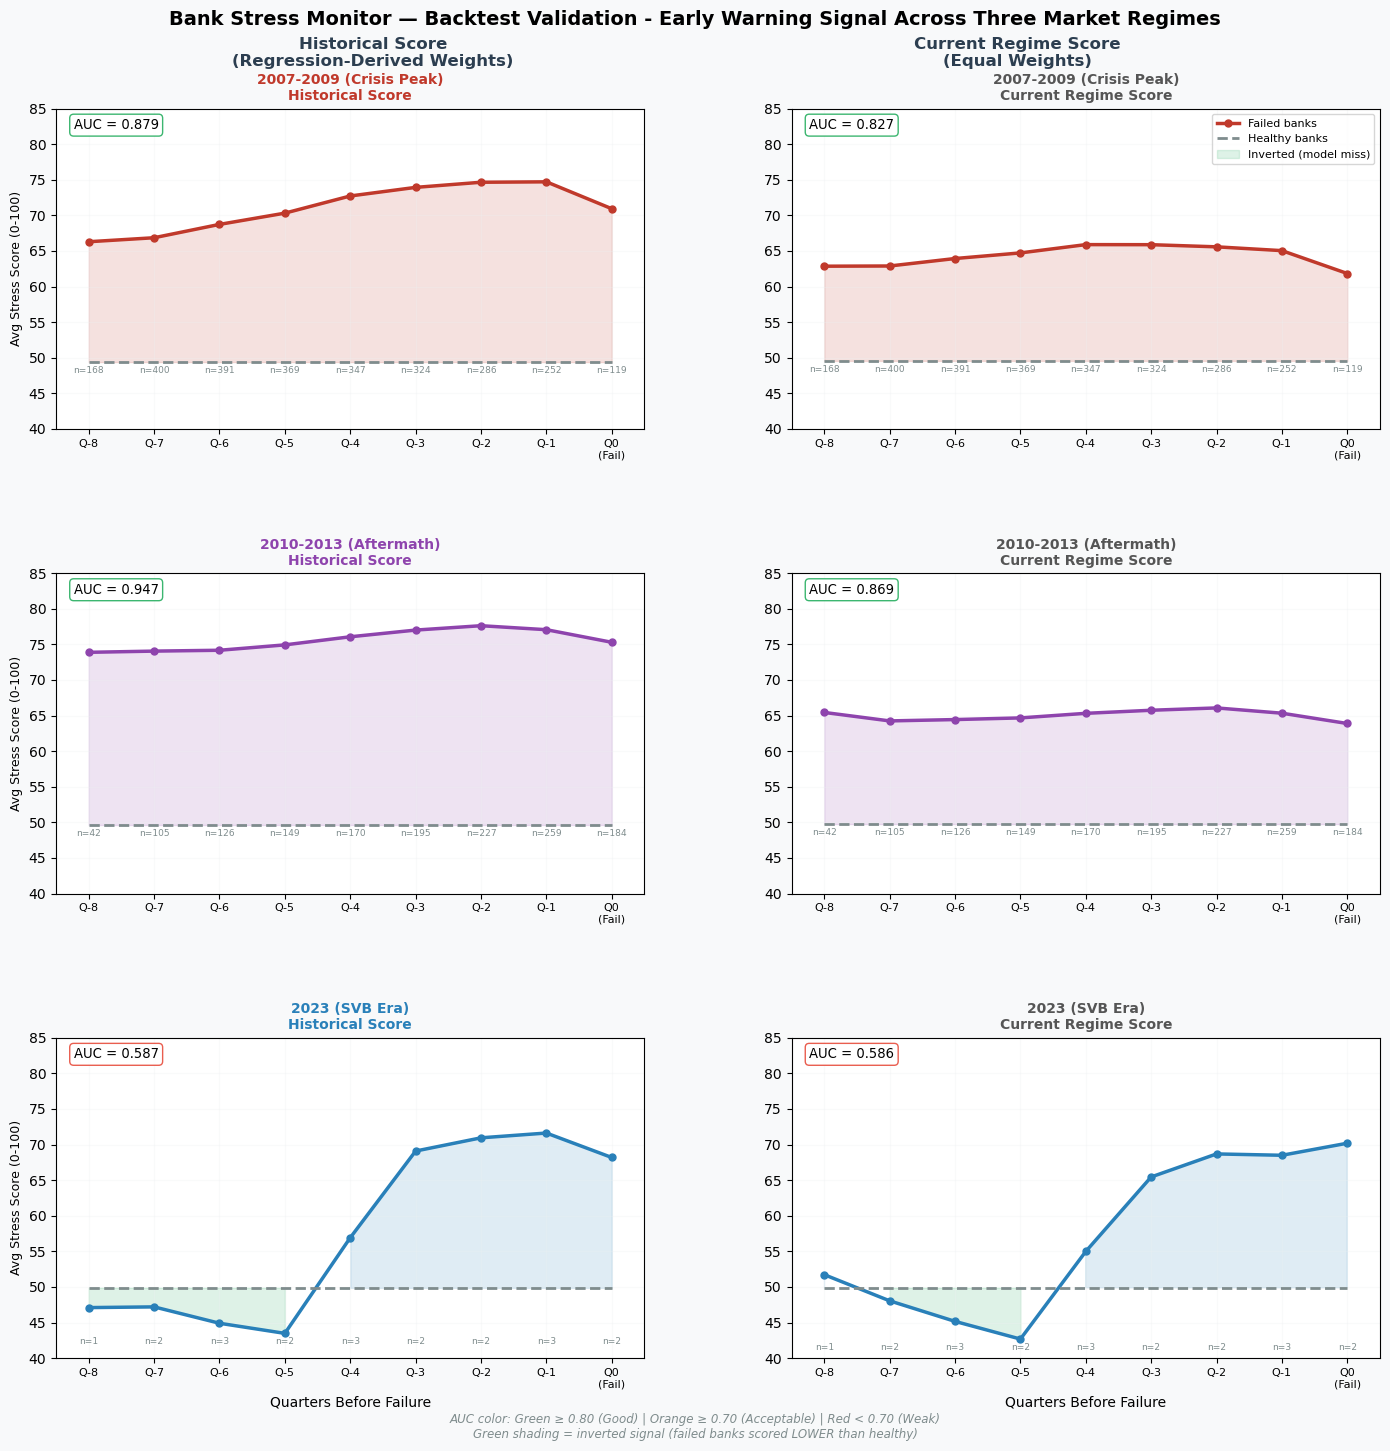

Saved: backtest_chart_full_final.png


In [22]:
# ============================================================
# VISUAL 1b: FULL BACKTEST GRID — 3 PERIODS × 2 SCORES
# ============================================================
# Layout: 3 rows × 2 columns
#   Row 1: 2007-2009 Crisis Peak
#   Row 2: 2010-2013 Aftermath
#   Row 3: 2023 SVB Era
#   Left col:  Historical Score
#   Right col: Current Regime Score
# ============================================================

# Define the three periods
periods = [
    {
        'name':   '2007-2009 (Crisis Peak)',
        'start':  '20070101',
        'end':    '20091231',
        'auc_h':  0.879,
        'auc_c':  0.827,
        'color':  '#C0392B',
    },
    {
        'name':   '2010-2013 (Aftermath)',
        'start':  '20100101',
        'end':    '20131231',
        'auc_h':  0.947,
        'auc_c':  0.869,
        'color':  '#8E44AD',
    },
    {
        'name':   '2023 (SVB Era)',
        'start':  '20230101',
        'end':    '20231231',
        'auc_h':  0.587,
        'auc_c':  0.586,
        'color':  '#2980B9',
    },
]

fig, axes = plt.subplots(
    3, 2, figsize=(14, 14)
)
fig.patch.set_facecolor('#F8F9FA')

for row_idx, period in enumerate(periods):

    # ── Prepare data for this period ──────────────────────
    period_df = backtest_df[
        (backtest_df['REPDTE'] >= period['start']) &
        (backtest_df['REPDTE'] <= period['end'])
    ].copy()

    failed = period_df[
        period_df['DEFAULT'] == 1
    ].copy()
    failed = failed[
        failed['QTRS_TO_FAILURE'].between(0, 8)
    ].copy()
    failed['QTRS_TO_FAILURE'] = (
        failed['QTRS_TO_FAILURE'].astype(int)
    )

    failed_avg = failed.groupby(
        'QTRS_TO_FAILURE'
    ).agg(
        hist_score=('HISTORICAL_SCORE', 'mean'),
        curr_score=('CURRENT_REGIME_SCORE', 'mean'),
        count=('CERT', 'count')
    ).reset_index().sort_values(
        'QTRS_TO_FAILURE', ascending=False
    )

    healthy = period_df[period_df['DEFAULT'] == 0]
    healthy_hist = healthy['HISTORICAL_SCORE'].mean()
    healthy_curr = healthy[
        'CURRENT_REGIME_SCORE'
    ].mean()

    # ── Plot both columns for this row ────────────────────
    for col_idx, (score_col, healthy_avg,
                   auc, score_label) in enumerate([
        ('hist_score', healthy_hist,
         period['auc_h'], 'Historical Score'),
        ('curr_score', healthy_curr,
         period['auc_c'], 'Current Regime Score'),
    ]):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor('#FFFFFF')

        if len(failed_avg) == 0:
            ax.text(0.5, 0.5,
                    'Insufficient data',
                    ha='center', va='center',
                    transform=ax.transAxes)
            continue

        x = failed_avg[
            'QTRS_TO_FAILURE'
        ].values
        y_failed = failed_avg[score_col].values
        y_healthy = np.full_like(
            x, healthy_avg, dtype=float
        )

        # Lines
        ax.plot(x, y_failed,
                color=period['color'],
                linewidth=2.5,
                marker='o', markersize=5,
                label='Failed banks', zorder=3)
        ax.plot(x, y_healthy,
                color='#7F8C8D',
                linewidth=2, linestyle='--',
                label='Healthy banks', zorder=3)

        # Shade gap
        ax.fill_between(
            x, y_failed, y_healthy,
            where=(y_failed >= y_healthy),
            alpha=0.15,
            color=period['color']
        )
        # Shade inverted gap (when model fails)
        ax.fill_between(
            x, y_failed, y_healthy,
            where=(y_failed < y_healthy),
            alpha=0.15,
            color='#27AE60',
            label='Inverted (model miss)'
        )

        # Sample counts
        for _, r in failed_avg.iterrows():
            q = int(r['QTRS_TO_FAILURE'])
            n = int(r['count'])
            y_min = min(y_failed.min(),
                        healthy_avg)
            ax.annotate(
                f'n={n}',
                xy=(q, y_min - 1.5),
                ha='center', fontsize=6.5,
                color='#7F8C8D'
            )

        # AUC box
        auc_color = (
            '#27AE60' if auc >= 0.80 else
            '#F39C12' if auc >= 0.70 else
            '#E74C3C'
        )
        ax.text(
            0.03, 0.97,
            f'AUC = {auc:.3f}',
            transform=ax.transAxes,
            fontsize=9.5,
            verticalalignment='top',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='white',
                edgecolor=auc_color,
                alpha=0.9
            )
        )

        # Formatting
        ax.set_xlim(8.5, -0.5)
        ax.set_ylim(40, 85)
        ax.grid(True, alpha=0.3,
                color='#ECF0F1')
        ax.set_xticks(range(0, 9))
        ax.set_xticklabels(
            [f'Q-{i}' if i > 0
             else 'Q0\n(Fail)'
             for i in range(0, 9)],
            fontsize=8
        )

        # Labels
        if row_idx == 2:
            ax.set_xlabel(
                'Quarters Before Failure',
                fontsize=10
            )
        if col_idx == 0:
            ax.set_ylabel(
                'Avg Stress Score (0-100)',
                fontsize=9
            )
            ax.set_title(
                f'{period["name"]}\n'
                f'{score_label}',
                fontsize=10,
                fontweight='bold',
                color=period['color']
            )
        else:
            ax.set_title(
                f'{period["name"]}\n'
                f'{score_label}',
                fontsize=10,
                fontweight='bold',
                color='#555555'
            )

        # Legend only on first row right panel
        if row_idx == 0 and col_idx == 1:
            ax.legend(
                fontsize=8,
                loc='upper right'
            )

# ── Column headers ────────────────────────────────────────
fig.text(
    0.27, 0.97,
    'Historical Score\n(Regression-Derived Weights)',
    ha='center', fontsize=12,
    fontweight='bold', color='#2C3E50'
)
fig.text(
    0.73, 0.97,
    'Current Regime Score\n(Equal Weights)',
    ha='center', fontsize=12,
    fontweight='bold', color='#2C3E50'
)

# ── Main title ────────────────────────────────────────────
fig.suptitle(
    'Bank Stress Monitor — Backtest Validation - Early Warning Signal Across Three Market Regimes',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

# ── Bottom annotation ─────────────────────────────────────
fig.text(
    0.5, -0.01,
    'AUC color: Green ≥ 0.80 (Good) | '
    'Orange ≥ 0.70 (Acceptable) | '
    'Red < 0.70 (Weak)\n'
    'Green shading = inverted signal '
    '(failed banks scored LOWER than healthy)',
    ha='center', fontsize=8.5,
    color='#7F8C8D',
    style='italic'
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.45, wspace=0.25)
plt.savefig(
    'backtest_chart_full_final.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)
plt.show()
print("Saved: backtest_chart_full_final.png")

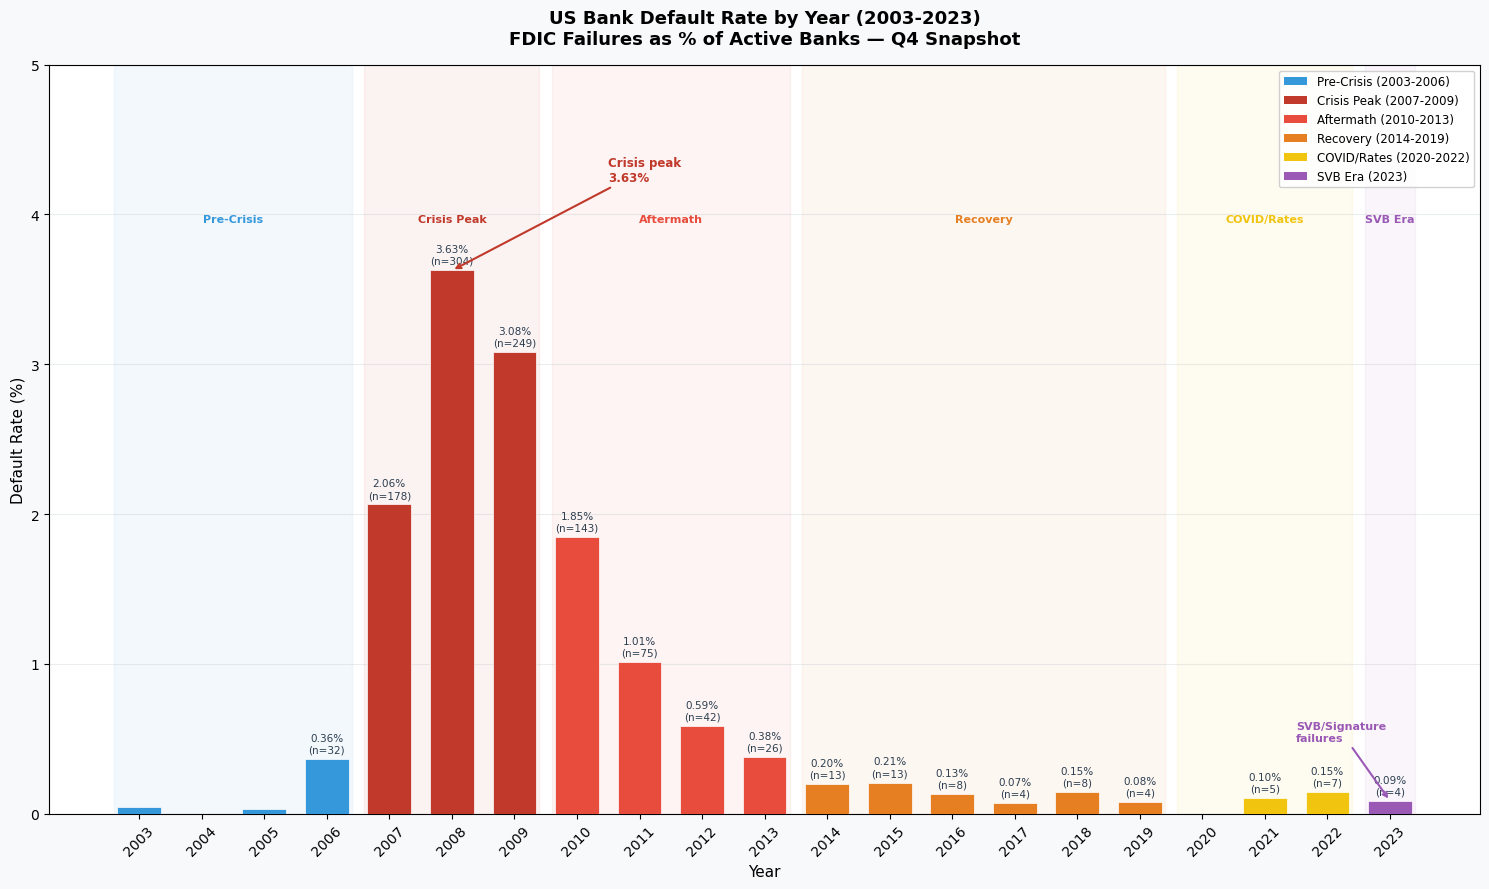

Saved: default_rate_by_year.png


In [23]:
# ============================================================
# VISUAL 2: DEFAULT RATE BY YEAR (2003-2023)
# ============================================================
# Purpose: Show the historical default rate landscape
#          Sets context for why the model was trained
#          the way it was — 2008-2012 dominates
# ============================================================

# ── Prepare data ──────────────────────────────────────────
yearly = historical_df.copy()
yearly['YEAR'] = yearly['REPDTE'].astype(str).str[:4]

# One observation per bank per year
# Use Q4 snapshot (last quarter of each year)
yearly_q4 = yearly[
    yearly['REPDTE'].astype(str).str[4:6] == '12'
].copy()

yearly_stats = yearly_q4.groupby('YEAR').agg(
    total_banks=('CERT', 'count'),
    defaults=('DEFAULT', 'sum')
).reset_index()

yearly_stats['default_rate'] = (
    100 * yearly_stats['defaults'] /
    yearly_stats['total_banks']
)

# ── Color by period ───────────────────────────────────────
def get_bar_color(year):
    y = int(year)
    if 2003 <= y <= 2006:
        return '#3498DB'   # Blue — pre-crisis
    elif 2007 <= y <= 2009:
        return '#C0392B'   # Red — crisis peak
    elif 2010 <= y <= 2013:
        return '#E74C3C'   # Light red — aftermath
    elif 2014 <= y <= 2019:
        return '#E67E22'   # Orange — recovery
    elif 2020 <= y <= 2022:
        return '#F1C40F'   # Yellow — COVID/rates
    else:
        return '#9B59B6'   # Purple — SVB era

colors_bar = [
    get_bar_color(y)
    for y in yearly_stats['YEAR']
]

# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 9))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

bars = ax.bar(
    yearly_stats['YEAR'],
    yearly_stats['default_rate'],
    color=colors_bar,
    width=0.7,
    edgecolor='white',
    linewidth=0.5,
    zorder=3
)

# Add value labels on bars
for bar, rate, n_def in zip(
    bars,
    yearly_stats['default_rate'],
    yearly_stats['defaults']
):
    if rate > 0.05:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.03,
            f'{rate:.2f}%\n(n={int(n_def)})',
            ha='center', va='bottom',
            fontsize=7.5, color='#2C3E50'
        )

# ── Period shading ────────────────────────────────────────
period_bands = [
    ('2003', '2006', '#3498DB', 'Pre-Crisis'),
    ('2007', '2009', '#C0392B', 'Crisis Peak'),
    ('2010', '2013', '#E74C3C', 'Aftermath'),
    ('2014', '2019', '#E67E22', 'Recovery'),
    ('2020', '2022', '#F1C40F', 'COVID/Rates'),
    ('2023', '2023', '#9B59B6', 'SVB Era'),
]

years_list = yearly_stats['YEAR'].tolist()

for start, end, color, label in period_bands:
    # Find x positions
    try:
        x_start = years_list.index(start) - 0.4
        x_end   = years_list.index(end) + 0.4
        ax.axvspan(
            x_start, x_end,
            alpha=0.06, color=color, zorder=1
        )
        # Period label at top
        x_mid = (x_start + x_end) / 2
        ax.text(
            x_mid,
            4.0,
            label,
            ha='center', va='top',
            fontsize=8, color=color,
            fontweight='bold'
        )
    except ValueError:
        pass

# ── Annotations for key events ────────────────────────────
# Peak crisis year
peak_idx = yearly_stats[
    'default_rate'
].idxmax()
peak_year = yearly_stats.loc[peak_idx, 'YEAR']
peak_rate = yearly_stats.loc[
    peak_idx, 'default_rate'
]

ax.annotate(
    f'Crisis peak\n{peak_rate:.2f}%',
    xy=(years_list.index(peak_year),
        peak_rate),
    xytext=(years_list.index(peak_year) + 2.5,
            peak_rate + 0.6),
    fontsize=8.5,
    color='#C0392B',
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color='#C0392B',
        lw=1.5
    )
)

# SVB annotation
if '2023' in years_list:
    svb_idx = years_list.index('2023')
    svb_rate = yearly_stats.loc[
        yearly_stats['YEAR'] == '2023',
        'default_rate'
    ].values[0]
    ax.annotate(
        'SVB/Signature\nfailures',
        xy=(svb_idx, svb_rate),
        xytext=(svb_idx - 1.5, svb_rate + 0.4),
        fontsize=8,
        color='#9B59B6',
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',
            color='#9B59B6',
            lw=1.5
        )
    )

# ── Formatting ────────────────────────────────────────────
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_title(
    'US Bank Default Rate by Year (2003-2023)\n'
    'FDIC Failures as % of Active Banks — '
    'Q4 Snapshot',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.grid(
    True, axis='y',
    alpha=0.3, color='#BDC3C7',
    zorder=0
)
ax.set_ylim(0, 5)
ax.tick_params(axis='x', rotation=45)

# ── Legend ────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498DB',
          label='Pre-Crisis (2003-2006)'),
    Patch(facecolor='#C0392B',
          label='Crisis Peak (2007-2009)'),
    Patch(facecolor='#E74C3C',
          label='Aftermath (2010-2013)'),
    Patch(facecolor='#E67E22',
          label='Recovery (2014-2019)'),
    Patch(facecolor='#F1C40F',
          label='COVID/Rates (2020-2022)'),
    Patch(facecolor='#9B59B6',
          label='SVB Era (2023)'),
]
ax.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=8.5,
    framealpha=0.9
)

plt.tight_layout()
plt.savefig(
    'default_rate_by_year.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)
plt.show()
print("Saved: default_rate_by_year.png")

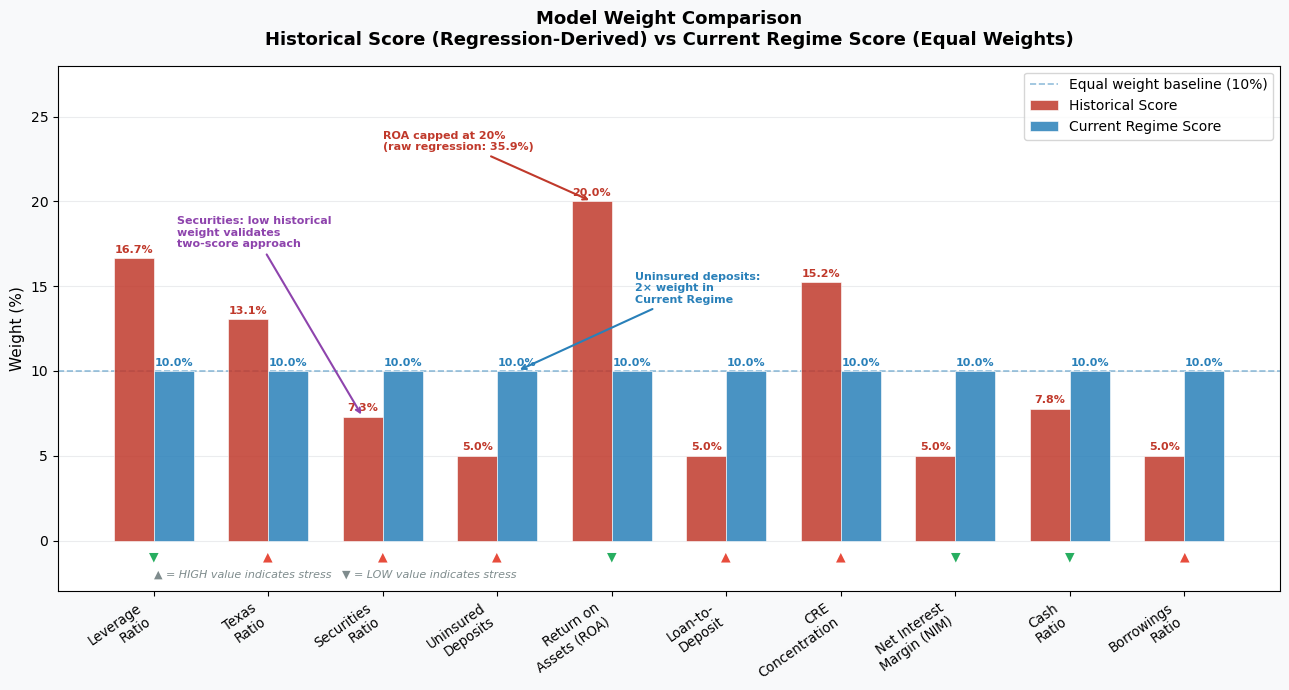

Saved: weight_comparison.png


In [24]:
# ============================================================
# VISUAL 3: WEIGHT COMPARISON BAR CHART
# ============================================================
# Purpose: Show Historical vs Equal weights for all 10
#          ratios side by side
#          Immediately explains the two-score philosophy
#          and where the models differ
# ============================================================

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

# ── Data ──────────────────────────────────────────────────
ratios = RATIO_COLS
hist_weights = [final_weights[r] * 100
                for r in ratios]
curr_weights = [10.0 for _ in ratios]

# Full descriptive names for display
ratio_labels = [
    'Leverage\nRatio',
    'Texas\nRatio',
    'Securities\nRatio',
    'Uninsured\nDeposits',
    'Return on\nAssets (ROA)',
    'Loan-to-\nDeposit',
    'CRE\nConcentration',
    'Net Interest\nMargin (NIM)',
    'Cash\nRatio',
    'Borrowings\nRatio'
]

x = np.arange(len(ratios))
width = 0.35

# ── Bars ──────────────────────────────────────────────────
bars_hist = ax.bar(
    x - width/2, hist_weights,
    width, label='Historical Score',
    color='#C0392B', alpha=0.85,
    edgecolor='white', linewidth=0.5,
    zorder=3
)
bars_curr = ax.bar(
    x + width/2, curr_weights,
    width, label='Current Regime Score',
    color='#2980B9', alpha=0.85,
    edgecolor='white', linewidth=0.5,
    zorder=3
)

# ── Value labels on bars ───────────────────────────────────
for bar, val in zip(bars_hist, hist_weights):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=8, color='#C0392B',
        fontweight='bold'
    )

for bar in bars_curr:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        10.0 + 0.2,
        '10.0%',
        ha='center', va='bottom',
        fontsize=8, color='#2980B9',
        fontweight='bold'
    )

# ── Equal weight reference line ───────────────────────────
ax.axhline(
    y=10, color='#2980B9',
    linestyle='--', linewidth=1.2,
    alpha=0.5, zorder=2,
    label='Equal weight baseline (10%)'
)

# ── Highlight key differences ─────────────────────────────
# ROA — most overweighted historically
roa_idx = ratios.index('ROA')
ax.annotate(
    'ROA capped at 20%\n(raw regression: 35.9%)',
    xy=(roa_idx - width/2,
        hist_weights[roa_idx]),
    xytext=(roa_idx - 2.0,
            hist_weights[roa_idx] + 3.0),
    fontsize=8, color='#C0392B',
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color='#C0392B', lw=1.5
    )
)

# Securities — most underweighted historically
sec_idx = ratios.index('SECURITIES_RATIO')
ax.annotate(
    'Securities: low historical\nweight validates\ntwo-score approach',
    xy=(sec_idx - width/2,
        hist_weights[sec_idx]),
    xytext=(sec_idx - 1.8,
            hist_weights[sec_idx] + 10.0),
    fontsize=8, color='#8E44AD',
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color='#8E44AD', lw=1.5
    )
)

# Uninsured deposits — doubled in current regime
unins_idx = ratios.index('UNINSURED_DEP_RATIO')
ax.annotate(
    'Uninsured deposits:\n2× weight in\nCurrent Regime',
    xy=(unins_idx + width/2,
        10.0),
    xytext=(unins_idx + 1.2,
            14.0),
    fontsize=8, color='#2980B9',
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color='#2980B9', lw=1.5
    )
)

# ── Stress direction labels ────────────────────────────────
for i, ratio in enumerate(ratios):
    direction = STRESS_DIRECTION[ratio]
    symbol = '▲' if direction == 'HIGH' else '▼'
    color = '#E74C3C' if direction == 'HIGH' \
            else '#27AE60'
    ax.text(
        i, -1.2, symbol,
        ha='center', fontsize=9,
        color=color
    )

# Direction legend
ax.text(
    0, -2.2,
    '▲ = HIGH value indicates stress   '
    '▼ = LOW value indicates stress',
    fontsize=8, color='#7F8C8D',
    style='italic'
)

# ── Formatting ────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(
    ratio_labels, rotation=35,
    ha='right', fontsize=9.5
)
ax.set_ylabel('Weight (%)', fontsize=11)
ax.set_ylim(-3, 28)
ax.set_title(
    'Model Weight Comparison\n'
    'Historical Score (Regression-Derived) vs '
    'Current Regime Score (Equal Weights)',
    fontsize=13, fontweight='bold', pad=15
)
ax.grid(
    True, axis='y',
    alpha=0.3, color='#BDC3C7',
    zorder=0
)
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig(
    'weight_comparison.png',
    dpi=150, bbox_inches='tight',
    facecolor=fig.get_facecolor()
)
plt.show()
print("Saved: weight_comparison.png")

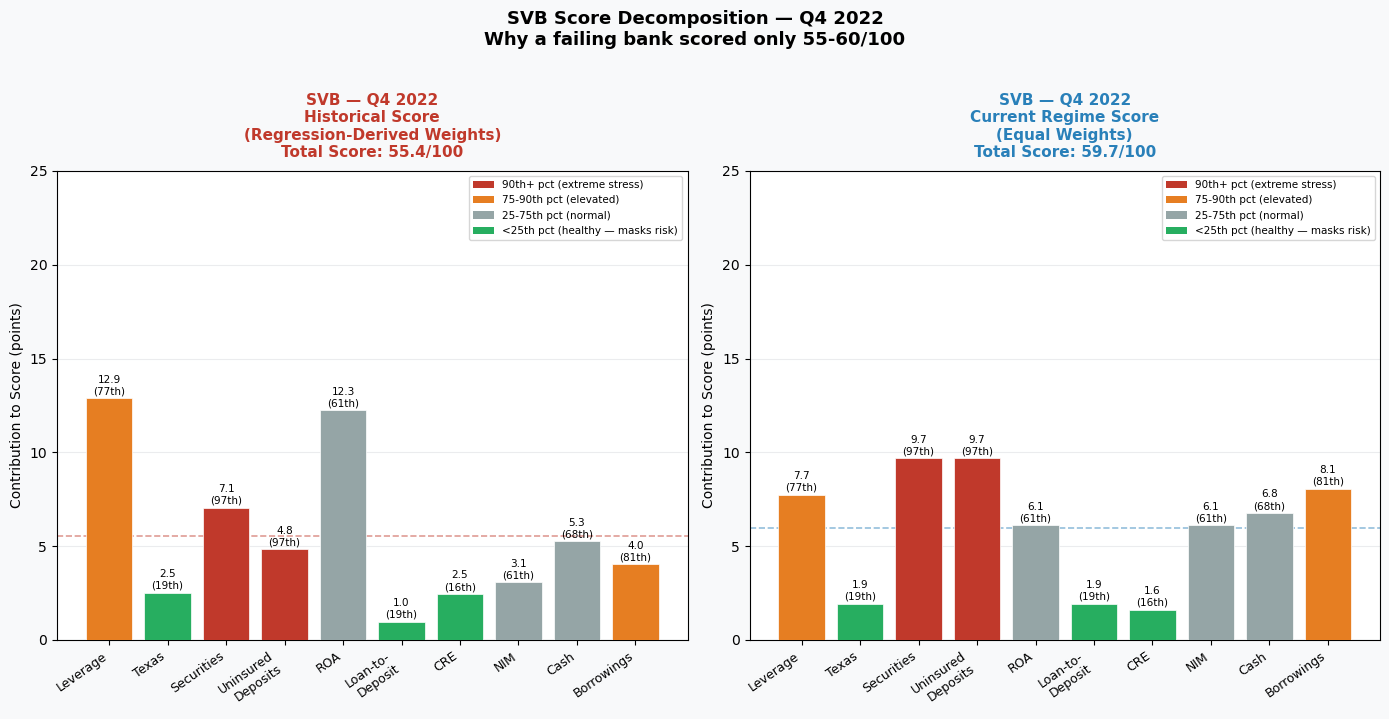

Saved: svb_decomposition.png


In [25]:
# ============================================================
# VISUAL 4: SVB SCORE DECOMPOSITION (Q4 2022)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#F8F9FA')

last_q = svb_detail.iloc[-1]

ratio_labels_short = [
    'Leverage', 'Texas', 'Securities',
    'Uninsured\nDeposits', 'ROA',
    'Loan-to-\nDeposit', 'CRE', 'NIM',
    'Cash', 'Borrowings'
]

for ax_idx, (ax, score_type, weights, title, color) in enumerate(zip(
    axes,
    ['HISTORICAL_SCORE', 'CURRENT_REGIME_SCORE'],
    [final_weights, current_regime_weights],
    ['Historical Score\n(Regression-Derived Weights)',
     'Current Regime Score\n(Equal Weights)'],
    ['#C0392B', '#2980B9']
)):
    ax.set_facecolor('#FFFFFF')

    contribs = []
    colors_bar = []

    for r in RATIO_COLS:
        pct_col = f"{r}_PCT"
        pct = last_q[pct_col]
        w = weights[r]
        contrib = pct * w 
        contribs.append(contrib)

        # Color by stress level
        if pct >= 90:
            colors_bar.append('#C0392B')
        elif pct >= 75:
            colors_bar.append('#E67E22')
        elif pct <= 25:
            colors_bar.append('#27AE60')
        else:
            colors_bar.append('#95A5A6')

    x = np.arange(len(RATIO_COLS))
    bars = ax.bar(
        x, contribs,
        color=colors_bar,
        edgecolor='white',
        linewidth=0.5,
        zorder=3
    )

    # Value labels
    for bar, val, pct in zip(
        bars, contribs,
        [last_q[f"{r}_PCT"] for r in RATIO_COLS]
    ):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val:.1f}\n({pct:.0f}th)',
            ha='center', va='bottom',
            fontsize=7.5
        )

    # Total score line
    total = sum(contribs)
    ax.axhline(
        y=total/len(RATIO_COLS),
        color=color, linestyle='--',
        linewidth=1.2, alpha=0.5
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        ratio_labels_short,
        rotation=35, ha='right', fontsize=9
    )
    ax.set_ylabel(
        'Contribution to Score (points)',
        fontsize=10
    )
    ax.set_ylim(0, 25)
    ax.set_title(
        f'SVB — Q4 2022\n{title}\n'
        f'Total Score: {last_q[score_type]:.1f}/100',
        fontsize=11, fontweight='bold',
        color=color, pad=10
    )
    ax.grid(
        True, axis='y',
        alpha=0.3, color='#BDC3C7'
    )

    # Color legend
    from matplotlib.patches import Patch
    legend_els = [
        Patch(facecolor='#C0392B',
              label='90th+ pct (extreme stress)'),
        Patch(facecolor='#E67E22',
              label='75-90th pct (elevated)'),
        Patch(facecolor='#95A5A6',
              label='25-75th pct (normal)'),
        Patch(facecolor='#27AE60',
              label='<25th pct (healthy — masks risk)'),
    ]
    ax.legend(
        handles=legend_els,
        fontsize=7.5, loc='upper right'
    )

fig.suptitle(
    'SVB Score Decomposition — Q4 2022\n'
    'Why a failing bank scored only 55-60/100',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    'svb_decomposition.png',
    dpi=150, bbox_inches='tight',
    facecolor=fig.get_facecolor()
)
plt.show()
print("Saved: svb_decomposition.png")

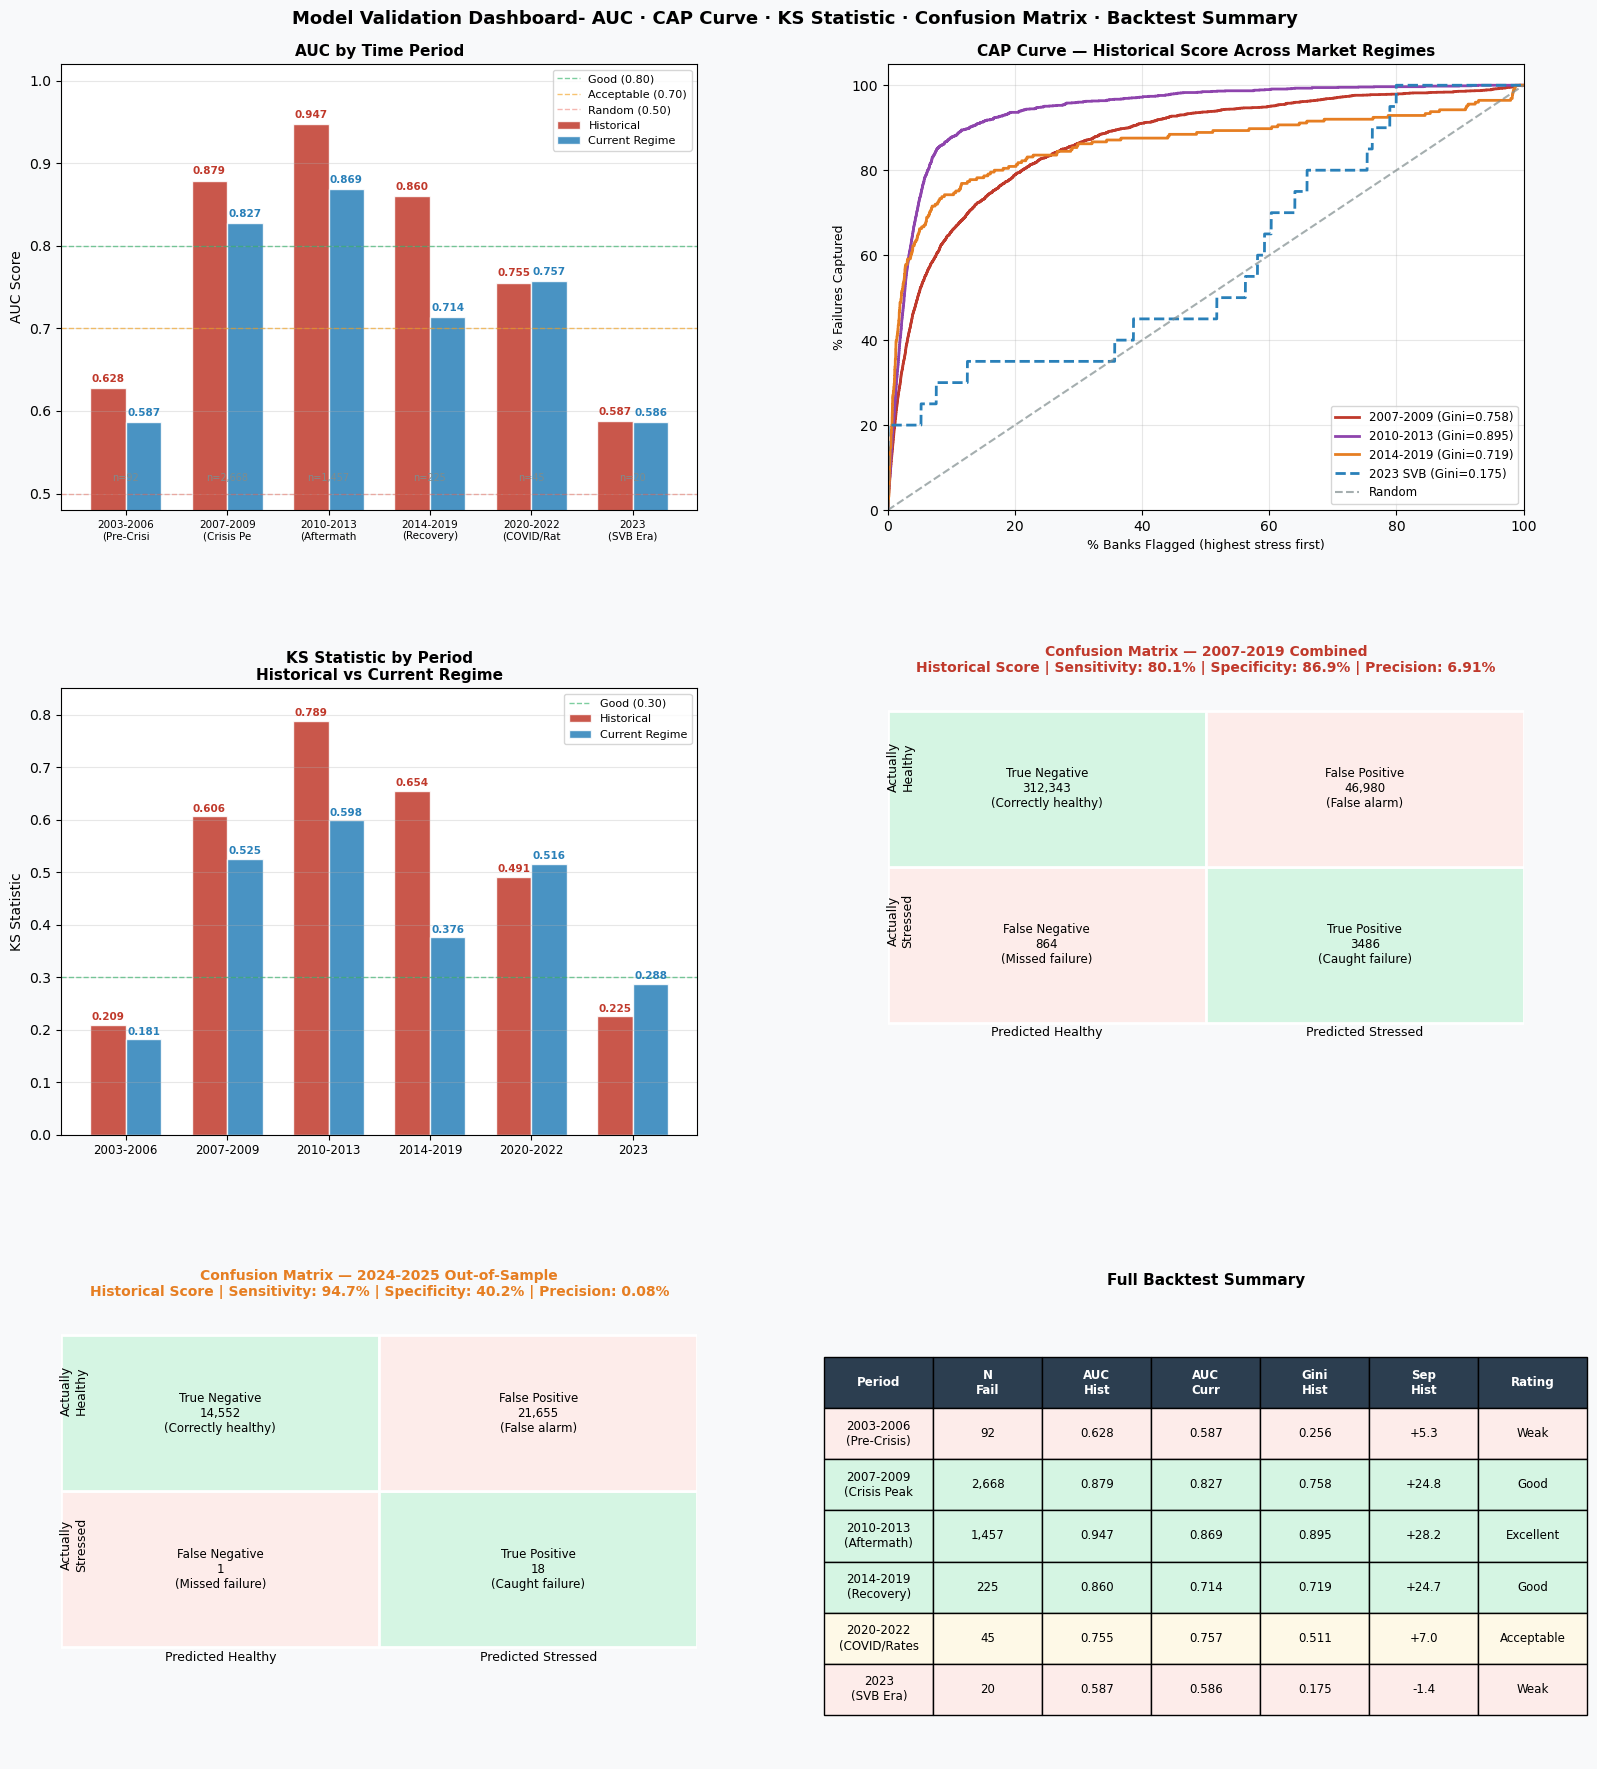

Saved: validation_dashboard_final.png


In [26]:
# ============================================================
# VISUAL 5 FINAL: COMPLETE VALIDATION DASHBOARD
# 6 panels:
#   Row 1: AUC by period | CAP curves (4 periods)
#   Row 2: KS bar chart  | Confusion matrix (2007-2019)
#   Row 3: Confusion matrix (2024-2025) | Full summary table
# ============================================================

from sklearn.metrics import confusion_matrix, roc_curve

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.patch.set_facecolor('#F8F9FA')

# ── Helper: prepare period data ───────────────────────────
def get_period_data(start, end):
    df = backtest_df[
        (backtest_df['REPDTE'] >= start) &
        (backtest_df['REPDTE'] <= end)
    ].dropna(subset=[
        'HISTORICAL_SCORE',
        'CURRENT_REGIME_SCORE',
        'DEFAULT'
    ]).copy()
    y = df['DEFAULT'].values
    h = df['HISTORICAL_SCORE'].values / 100
    c = df['CURRENT_REGIME_SCORE'].values / 100
    return y, h, c

# ══════════════════════════════════════════════════════════
# PANEL 1 (row 1 left): AUC by period
# ══════════════════════════════════════════════════════════
ax1 = axes[0, 0]
ax1.set_facecolor('#FFFFFF')

periods_bt  = [r['Group'][:20]
                for r in all_group_results]
auc_hist_bt = [r['AUC_Hist']
                for r in all_group_results]
auc_curr_bt = [r['AUC_Curr']
                for r in all_group_results]
n_def_bt    = [r['N_Defaults']
                for r in all_group_results]

x  = np.arange(len(periods_bt))
w  = 0.35

bh = ax1.bar(x - w/2, auc_hist_bt, w,
              label='Historical',
              color='#C0392B', alpha=0.85,
              edgecolor='white')
bc = ax1.bar(x + w/2, auc_curr_bt, w,
              label='Current Regime',
              color='#2980B9', alpha=0.85,
              edgecolor='white')

for bar, val in zip(bh, auc_hist_bt):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{val:.3f}', ha='center',
        va='bottom', fontsize=7.5,
        color='#C0392B', fontweight='bold'
    )
for bar, val in zip(bc, auc_curr_bt):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{val:.3f}', ha='center',
        va='bottom', fontsize=7.5,
        color='#2980B9', fontweight='bold'
    )
for i, n in enumerate(n_def_bt):
    ax1.text(i, 0.515, f'n={n:,}',
              ha='center', fontsize=7,
              color='#7F8C8D')

ax1.axhline(y=0.80, color='#27AE60',
             linestyle='--', linewidth=1,
             alpha=0.6, label='Good (0.80)')
ax1.axhline(y=0.70, color='#F39C12',
             linestyle='--', linewidth=1,
             alpha=0.6, label='Acceptable (0.70)')
ax1.axhline(y=0.50, color='#E74C3C',
             linestyle='--', linewidth=1,
             alpha=0.4, label='Random (0.50)')

ax1.set_xticks(x)
ax1.set_xticklabels(
    [p.replace(' (', '\n(')
     for p in periods_bt],
    fontsize=7.5
)
ax1.set_ylim(0.48, 1.02)
ax1.set_ylabel('AUC Score', fontsize=10)
ax1.set_title('AUC by Time Period',
               fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, axis='y', alpha=0.3)

# ══════════════════════════════════════════════════════════
# PANEL 2 (row 1 right): CAP curves — 4 periods
# ══════════════════════════════════════════════════════════
ax2 = axes[0, 1]
ax2.set_facecolor('#FFFFFF')

cap_periods = [
    ('2007-2009', '20070101', '20091231',
     '#C0392B', '-'),
    ('2010-2013', '20100101', '20131231',
     '#8E44AD', '-'),
    ('2014-2019', '20140101', '20191231',
     '#E67E22', '-'),
    ('2023 SVB',  '20230101', '20231231',
     '#2980B9', '--'),
]

for label, start, end, color, ls in cap_periods:
    y_t, y_h, y_c = get_period_data(start, end)
    if y_t.sum() < 5:
        continue
    cap_x, cap_y, gini = cap_curve_gini(y_t, y_h)
    ax2.plot(
        cap_x, cap_y,
        color=color, linewidth=2,
        linestyle=ls,
        label=f'{label} (Gini={gini:.3f})'
    )

# Random line
ax2.plot([0, 100], [0, 100],
          color='#7F8C8D', linewidth=1.5,
          linestyle='--', label='Random',
          alpha=0.7)

ax2.set_xlim(0, 100)
ax2.set_ylim(0, 105)
ax2.set_xlabel(
    '% Banks Flagged (highest stress first)',
    fontsize=9
)
ax2.set_ylabel('% Failures Captured', fontsize=9)
ax2.set_title(
    'CAP Curve — Historical Score Across Market Regimes',
    fontsize=11, fontweight='bold'
)
ax2.legend(fontsize=8.5, loc='lower right')
ax2.grid(True, alpha=0.3)

# ══════════════════════════════════════════════════════════
# PANEL 3 (row 2 left): KS bar chart — all periods
# ══════════════════════════════════════════════════════════
ax3 = axes[1, 0]
ax3.set_facecolor('#FFFFFF')

ks_periods = []
ks_hist_vals = []
ks_curr_vals = []

period_ranges = [
    ('2003-2006', '20030101', '20061231'),
    ('2007-2009', '20070101', '20091231'),
    ('2010-2013', '20100101', '20131231'),
    ('2014-2019', '20140101', '20191231'),
    ('2020-2022', '20200101', '20221231'),
    ('2023',      '20230101', '20231231'),
]

for label, start, end in period_ranges:
    y_t, y_h, y_c = get_period_data(start, end)
    if y_t.sum() < 5:
        ks_periods.append(label)
        ks_hist_vals.append(0)
        ks_curr_vals.append(0)
        continue
    fpr_h, tpr_h, _ = roc_curve(y_t, y_h)
    fpr_c, tpr_c, _ = roc_curve(y_t, y_c)
    ks_h = float(max(tpr_h - fpr_h))
    ks_c = float(max(tpr_c - fpr_c))
    ks_periods.append(label)
    ks_hist_vals.append(ks_h)
    ks_curr_vals.append(ks_c)

x_ks = np.arange(len(ks_periods))
bh_ks = ax3.bar(
    x_ks - w/2, ks_hist_vals, w,
    label='Historical',
    color='#C0392B', alpha=0.85,
    edgecolor='white'
)
bc_ks = ax3.bar(
    x_ks + w/2, ks_curr_vals, w,
    label='Current Regime',
    color='#2980B9', alpha=0.85,
    edgecolor='white'
)

for bar, val in zip(bh_ks, ks_hist_vals):
    if val > 0:
        ax3.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center',
            va='bottom', fontsize=7.5,
            color='#C0392B', fontweight='bold'
        )
for bar, val in zip(bc_ks, ks_curr_vals):
    if val > 0:
        ax3.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center',
            va='bottom', fontsize=7.5,
            color='#2980B9', fontweight='bold'
        )

ax3.axhline(y=0.30, color='#27AE60',
             linestyle='--', linewidth=1,
             alpha=0.6, label='Good (0.30)')
ax3.set_xticks(x_ks)
ax3.set_xticklabels(
    ks_periods, fontsize=8.5
)
ax3.set_ylim(0, 0.85)
ax3.set_ylabel('KS Statistic', fontsize=10)
ax3.set_title(
    'KS Statistic by Period\nHistorical vs Current Regime',
    fontsize=11, fontweight='bold'
)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(True, axis='y', alpha=0.3)

# ══════════════════════════════════════════════════════════
# PANEL 4 (row 2 right): Confusion matrix 2007-2019
# ══════════════════════════════════════════════════════════
ax4 = axes[1, 1]
ax4.set_facecolor('#FFFFFF')
ax4.axis('off')

y_t_main, y_h_main, y_c_main = get_period_data(
    '20070101', '20191231'
)
fpr_m, tpr_m, thresh_m = roc_curve(
    y_t_main, y_h_main
)
ks_thresh_main = thresh_m[
    np.argmax(tpr_m - fpr_m)
]
y_pred_main = (
    y_h_main >= ks_thresh_main
).astype(int)
cm_main = confusion_matrix(y_t_main, y_pred_main)
tn, fp, fn, tp = cm_main.ravel()

sens_m = tp / (tp + fn)
spec_m = tn / (tn + fp)
prec_m = tp / (tp + fp) if (tp+fp) > 0 else 0

labels_cm = np.array([
    [f'True Negative\n{tn:,}\n(Correctly healthy)',
     f'False Positive\n{fp:,}\n(False alarm)'],
    [f'False Negative\n{fn}\n(Missed failure)',
     f'True Positive\n{tp}\n(Caught failure)']
])
cell_colors = [
    ['#D5F5E3', '#FDECEA'],
    ['#FDECEA', '#D5F5E3']
]

for i in range(2):
    for j in range(2):
        ax4.add_patch(plt.Rectangle(
            (j*0.5, 0.25 + i*0.35),
            0.5, 0.35,
            facecolor=cell_colors[1-i][j],
            edgecolor='white', linewidth=2,
            transform=ax4.transAxes
        ))
        ax4.text(
            j*0.5 + 0.25,
            0.25 + i*0.35 + 0.175,
            labels_cm[1-i][j],
            ha='center', va='center',
            fontsize=8.5,
            transform=ax4.transAxes
        )

# Axis labels
ax4.text(0.25, 0.22, 'Predicted Healthy',
          ha='center', fontsize=9,
          transform=ax4.transAxes)
ax4.text(0.75, 0.22, 'Predicted Stressed',
          ha='center', fontsize=9,
          transform=ax4.transAxes)
ax4.text(0.02, 0.425, 'Actually\nStressed',
          ha='center', fontsize=9,
          rotation=90,
          transform=ax4.transAxes)
ax4.text(0.02, 0.775, 'Actually\nHealthy',
          ha='center', fontsize=9,
          rotation=90,
          transform=ax4.transAxes)

ax4.set_title(
    f'Confusion Matrix — 2007-2019 Combined\n'
    f'Historical Score | '
    f'Sensitivity: {sens_m:.1%} | '
    f'Specificity: {spec_m:.1%} | '
    f'Precision: {prec_m:.2%}',
    fontsize=10, fontweight='bold',
    color='#C0392B', pad=12
)

# ══════════════════════════════════════════════════════════
# PANEL 5 (row 3 left): Confusion matrix 2024-2025
# ══════════════════════════════════════════════════════════
ax5 = axes[2, 0]
ax5.set_facecolor('#FFFFFF')
ax5.axis('off')

val_clean2 = validation_scored.dropna(
    subset=['HISTORICAL_SCORE',
            'CURRENT_REGIME_SCORE', 'DEFAULT']
).copy()
y_t_v  = val_clean2['DEFAULT'].values
y_h_v  = val_clean2['HISTORICAL_SCORE'].values / 100

fpr_v, tpr_v, thresh_v = roc_curve(y_t_v, y_h_v)
ks_thresh_v = thresh_v[
    np.argmax(tpr_v - fpr_v)
]
y_pred_v = (y_h_v >= ks_thresh_v).astype(int)
cm_v = confusion_matrix(y_t_v, y_pred_v)
tn_v, fp_v, fn_v, tp_v = cm_v.ravel()

sens_v = tp_v / (tp_v + fn_v)
spec_v = tn_v / (tn_v + fp_v)
prec_v = tp_v / (tp_v + fp_v) \
         if (tp_v + fp_v) > 0 else 0

labels_v = np.array([
    [f'True Negative\n{tn_v:,}\n(Correctly healthy)',
     f'False Positive\n{fp_v:,}\n(False alarm)'],
    [f'False Negative\n{fn_v}\n(Missed failure)',
     f'True Positive\n{tp_v}\n(Caught failure)']
])

for i in range(2):
    for j in range(2):
        ax5.add_patch(plt.Rectangle(
            (j*0.5, 0.25 + i*0.35),
            0.5, 0.35,
            facecolor=cell_colors[1-i][j],
            edgecolor='white', linewidth=2,
            transform=ax5.transAxes
        ))
        ax5.text(
            j*0.5 + 0.25,
            0.25 + i*0.35 + 0.175,
            labels_v[1-i][j],
            ha='center', va='center',
            fontsize=8.5,
            transform=ax5.transAxes
        )

ax5.text(0.25, 0.22, 'Predicted Healthy',
          ha='center', fontsize=9,
          transform=ax5.transAxes)
ax5.text(0.75, 0.22, 'Predicted Stressed',
          ha='center', fontsize=9,
          transform=ax5.transAxes)
ax5.text(0.02, 0.425, 'Actually\nStressed',
          ha='center', fontsize=9,
          rotation=90,
          transform=ax5.transAxes)
ax5.text(0.02, 0.775, 'Actually\nHealthy',
          ha='center', fontsize=9,
          rotation=90,
          transform=ax5.transAxes)

ax5.set_title(
    f'Confusion Matrix — 2024-2025 Out-of-Sample\n'
    f'Historical Score | '
    f'Sensitivity: {sens_v:.1%} | '
    f'Specificity: {spec_v:.1%} | '
    f'Precision: {prec_v:.2%}',
    fontsize=10, fontweight='bold',
    color='#E67E22', pad=12
)

# ══════════════════════════════════════════════════════════
# PANEL 6 (row 3 right): Full summary table
# ══════════════════════════════════════════════════════════
ax6 = axes[2, 1]
ax6.set_facecolor('#FFFFFF')
ax6.axis('off')

table_data = []
for r in all_group_results:
    auc_h = r['AUC_Hist']
    if auc_h >= 0.90:   rating = 'Excellent'
    elif auc_h >= 0.80: rating = 'Good'
    elif auc_h >= 0.70: rating = 'Acceptable'
    else:               rating = 'Weak'

    table_data.append([
        r['Group'][:22].replace(' (', '\n('),
        f"{r['N_Defaults']:,}",
        f"{r['AUC_Hist']:.3f}",
        f"{r['AUC_Curr']:.3f}",
        f"{r['Gini_Hist']:.3f}",
        f"{r['Sep_Hist']:+.1f}",
        rating
    ])

col_labels = [
    'Period', 'N\nFail',
    'AUC\nHist', 'AUC\nCurr',
    'Gini\nHist', 'Sep\nHist',
    'Rating'
]

table = ax6.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.2, 2.8)

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(
        color='white', fontweight='bold'
    )

rating_colors = {
    'Excellent': '#D5F5E3',
    'Good':      '#D5F5E3',
    'Acceptable':'#FEF9E7',
    'Weak':      '#FDECEA'
}
for i, row in enumerate(table_data):
    rating = row[-1]
    color  = rating_colors.get(rating, '#FFFFFF')
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(color)

ax6.set_title(
    'Full Backtest Summary',
    fontsize=11, fontweight='bold', pad=20
)

# ── Main title ────────────────────────────────────────────
fig.suptitle(
    'Model Validation Dashboard- '
    'AUC · CAP Curve · KS Statistic · '
    'Confusion Matrix · Backtest Summary',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.95)
plt.savefig(
    'validation_dashboard_final.png',
    dpi=150, bbox_inches='tight',
    facecolor=fig.get_facecolor()
)
plt.show()
print("Saved: validation_dashboard_final.png")

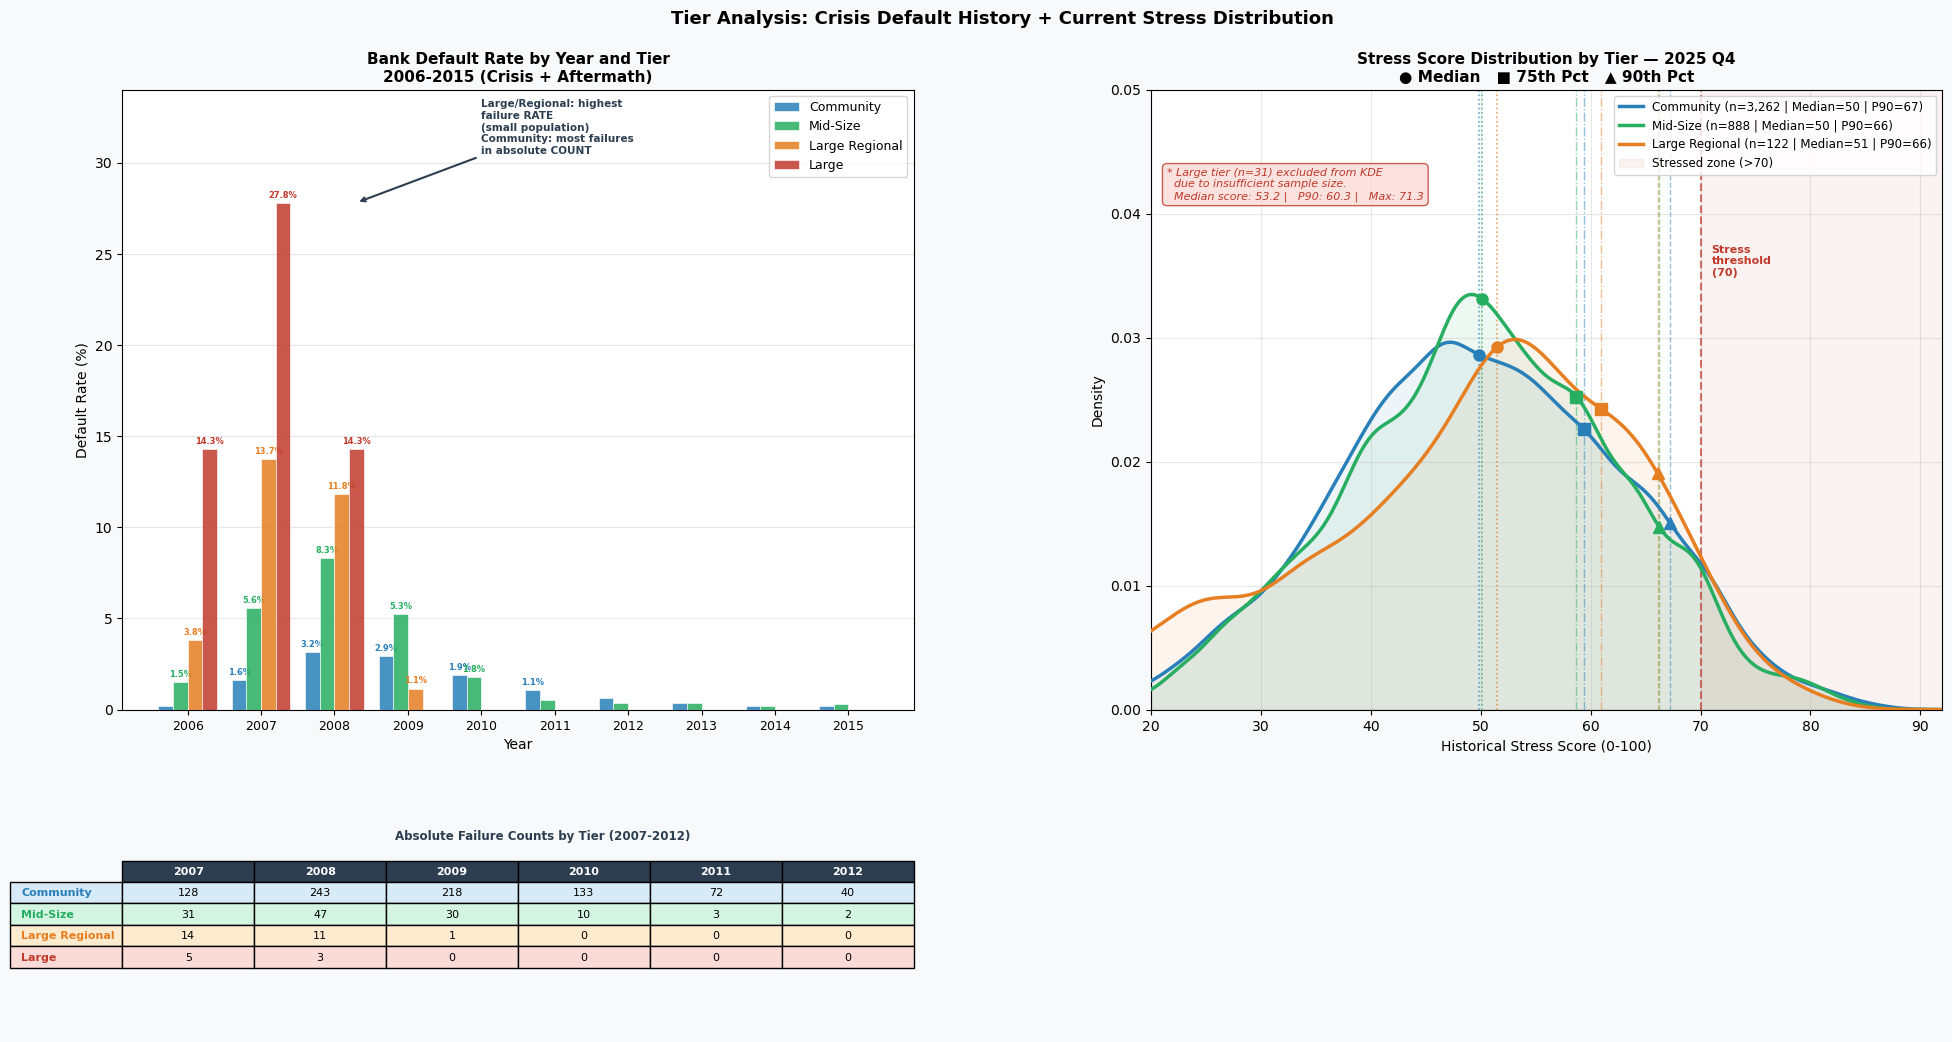

Saved: tier_analysis.png


In [27]:
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(20,10))
fig.patch.set_facecolor('#F8F9FA')

# Custom layout — left panel wider, right panel normal
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

tier_colors = {
    'Community':      '#2980B9',
    'Mid-Size':       '#27AE60',
    'Large Regional': '#E67E22',
    'Large':          '#C0392B'
}
tier_order = [
    'Community', 'Mid-Size',
    'Large Regional', 'Large'
]

# ══════════════════════════════════════════════════════════
# PANEL 1: Default rate + count table
# ══════════════════════════════════════════════════════════
ax1.set_facecolor('#FFFFFF')

yearly_tier = historical_df[
    historical_df['REPDTE'].astype(str).str[4:6] == '12'
].copy()
yearly_tier['YEAR'] = (
    yearly_tier['REPDTE'].astype(str).str[:4]
)

yearly_tier_stats = yearly_tier.groupby(
    ['YEAR', 'SIZE_TIER']
).agg(
    total=('CERT', 'count'),
    defaults=('DEFAULT', 'sum')
).reset_index()

yearly_tier_stats['default_rate'] = (
    100 * yearly_tier_stats['defaults'] /
    yearly_tier_stats['total']
)

focus_years = [str(y) for y in range(2006, 2016)]
plot_data = yearly_tier_stats[
    yearly_tier_stats['YEAR'].isin(focus_years)
].copy()

years_unique = sorted(plot_data['YEAR'].unique())
n_tiers = len(tier_order)
width   = 0.2
x       = np.arange(len(years_unique))

for i, tier in enumerate(tier_order):
    tier_data  = []
    for year in years_unique:
        row = plot_data[
            (plot_data['YEAR'] == year) &
            (plot_data['SIZE_TIER'] == tier)
        ]
        rate = row['default_rate'].values[0] \
               if len(row) > 0 else 0
        tier_data.append(rate)

    offset = (i - n_tiers/2 + 0.5) * width
    bars = ax1.bar(
        x + offset, tier_data, width,
        label=tier,
        color=tier_colors[tier],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5,
        zorder=3
    )

    for bar, val in zip(bars, tier_data):
        if val > 0.8:
            ax1.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.1f}%',
                ha='center', va='bottom',
                fontsize=6,
                color=tier_colors[tier],
                fontweight='bold'
            )

ax1.set_xticks(x)
ax1.set_xticklabels(years_unique, fontsize=9)
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('Default Rate (%)', fontsize=10)
ax1.set_title(
    'Bank Default Rate by Year and Tier\n'
    '2006-2015 (Crisis + Aftermath)',
    fontsize=11, fontweight='bold'
)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, axis='y', alpha=0.3)
ax1.set_ylim(0, 34)

# ── Annotation ─────────────────────────────────────────
# Calculate exact x position of Large bar in 2008
year_2008_idx = years_unique.index('2008')
large_tier_idx = tier_order.index('Large')
large_bar_x = (year_2008_idx +
               (large_tier_idx - n_tiers/2 + 0.5)
               * width)

ax1.annotate(
    'Large/Regional: highest\nfailure RATE\n'
    '(small population)\n'
    'Community: most failures\nin absolute COUNT',
    xy=(2.300, 27.8),
    xytext=(4.0, 30.5),
    fontsize=7.5,
    color='#2C3E50',
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color='#2C3E50', lw=1.5
    )
)

# ── Absolute count table below chart ──────────────────
# Build table data — absolute defaults per tier
# Key crisis years only to keep table manageable
table_years  = ['2007', '2008', '2009',
                 '2010', '2011', '2012']
table_tiers  = ['Community', 'Mid-Size',
                 'Large Regional', 'Large']
table_data   = []
for tier in table_tiers:
    row = []
    for year in table_years:
        match = yearly_tier_stats[
            (yearly_tier_stats['YEAR'] == year) &
            (yearly_tier_stats['SIZE_TIER'] == tier)
        ]
        val = int(match['defaults'].values[0]) \
              if len(match) > 0 else 0
        row.append(str(val))
    table_data.append(row)

table_ax = ax1.inset_axes([0, -0.52, 1, 0.38])
table_ax.axis('off')

tbl = table_ax.table(
    cellText=table_data,
    rowLabels=table_tiers,
    colLabels=table_years,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.6)

# Header styling
for j in range(len(table_years)):
    tbl[0, j].set_facecolor('#2C3E50')
    tbl[0, j].set_text_props(
        color='white', fontweight='bold'
    )

# Row colors matching tier colors
row_face_colors = {
    'Community':      '#D6EAF8',
    'Mid-Size':       '#D5F5E3',
    'Large Regional': '#FDEBD0',
    'Large':          '#FADBD8'
}
for i, tier in enumerate(table_tiers):
    # Row label cell
    tbl[i+1, -1].set_facecolor(
        row_face_colors[tier]
    )
    tbl[i+1, -1].set_text_props(
        fontweight='bold',
        color=tier_colors[tier]
    )
    for j in range(len(table_years)):
        tbl[i+1, j].set_facecolor(
            row_face_colors[tier]
        )

fig.text(
    0.27, 0.15,
    'Absolute Failure Counts by Tier (2007-2012)',
    ha='center', fontsize=8.5,
    fontweight='bold', color='#2C3E50'
)

# ══════════════════════════════════════════════════════════
# PANEL 2: KDE — Community, Mid-Size, Large Regional only
# ══════════════════════════════════════════════════════════
ax2.set_facecolor('#FFFFFF')

kde_tiers = [
    'Community', 'Mid-Size', 'Large Regional'
]

for tier in kde_tiers:
    tier_scores = current_output[
        current_output['SIZE_TIER'] == tier
    ]['HISTORICAL_SCORE'].dropna().values

    if len(tier_scores) < 10:
        continue

    bw  = 0.15 if len(tier_scores) > 200 else 0.25
    kde = gaussian_kde(
        tier_scores, bw_method=bw
    )
    x_range = np.linspace(20, 92, 400)
    density  = kde(x_range)

    n_banks  = len(tier_scores)
    median_s = np.median(tier_scores)
    p90_s    = np.percentile(tier_scores, 90)
    p75_s    = np.percentile(tier_scores, 75)

    ax2.plot(
        x_range, density,
        color=tier_colors[tier],
        linewidth=2.5,
        label=(f'{tier} (n={n_banks:,} | '
               f'Median={median_s:.0f} | '
               f'P90={p90_s:.0f})'),
        zorder=3
    )
    ax2.fill_between(
        x_range, density,
        alpha=0.08,
        color=tier_colors[tier]
    )

    # Median marker
    ax2.axvline(x=median_s,
                color=tier_colors[tier],
                linewidth=1.2, linestyle=':',
                alpha=0.7, zorder=2)
    ax2.plot(median_s, kde(median_s)[0],
             'o', color=tier_colors[tier],
             markersize=8, zorder=5)

    # P75 marker
    ax2.axvline(x=p75_s,
                color=tier_colors[tier],
                linewidth=1.0, linestyle='-.',
                alpha=0.5, zorder=2)
    ax2.plot(p75_s, kde(p75_s)[0],
             's', color=tier_colors[tier],
             markersize=8, zorder=5)

    # P90 marker
    ax2.axvline(x=p90_s,
                color=tier_colors[tier],
                linewidth=1.0, linestyle='--',
                alpha=0.5, zorder=2)
    ax2.plot(p90_s, kde(p90_s)[0],
             '^', color=tier_colors[tier],
             markersize=9, zorder=5)

# Stress zone
ax2.axvspan(
    70, 92, alpha=0.06,
    color='#C0392B',
    label='Stressed zone (>70)'
)
ax2.axvline(
    x=70, color='#C0392B',
    linestyle='--', linewidth=1.5,
    alpha=0.7
)
ax2.text(
    71, 0.035,
    'Stress\nthreshold\n(70)',
    color='#C0392B',
    fontsize=8, fontweight='bold'
)

# ── Large tier footnote box ────────────────────────────
large_scores = current_output[
    current_output['SIZE_TIER'] == 'Large'
]['HISTORICAL_SCORE'].dropna()

footnote = (
    f"* Large tier (n=31) excluded from KDE\n"
    f"  due to insufficient sample size.\n"
    f"  Median score: {large_scores.median():.1f} | "
    f"  P90: {large_scores.quantile(0.90):.1f} | "
    f"  Max: {large_scores.max():.1f}"
)
ax2.text(
    0.02, 0.82,
    footnote,
    transform=ax2.transAxes,
    fontsize=8,
    color='#C0392B',
    style='italic',
    verticalalignment='bottom',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#FADBD8',
        edgecolor='#C0392B',
        alpha=0.8
    )
)

ax2.set_xlabel(
    'Historical Stress Score (0-100)',
    fontsize=10
)
ax2.set_ylabel('Density', fontsize=10)
ax2.set_title(
    'Stress Score Distribution by Tier — 2025 Q4\n'
    '● Median   ■ 75th Pct   ▲ 90th Pct',
    fontsize=11, fontweight='bold'
)
ax2.legend(fontsize=8.5, loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(20, 92)
ax2.set_ylim(0, 0.05)

# ── Main title ────────────────────────────────────────
fig.suptitle(
    'Tier Analysis: '
    'Crisis Default History + '
    'Current Stress Distribution',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.subplots_adjust(top=0.90, bottom=0.28,
                    left=0.06, right=0.97,
                    wspace=0.3)
plt.savefig(
    'tier_analysis.png',
    dpi=150, bbox_inches='tight',
    facecolor=fig.get_facecolor()
)
plt.show()
print("Saved: tier_analysis.png")

In [28]:
# ============================================================
# COMPREHENSIVE DATA SAVE
# All outputs for Power BI, SQL, README
# ============================================================

import sqlite3
import json
import os

print("Saving all datasets...")
print("=" * 60)

# ── 1. Add driver columns to current snapshot ─────────────
print("Step 1: Adding driver analysis...")

def get_top_drivers(row, ratio_cols, weights, n=3):
    drivers = []
    for r in ratio_cols:
        pct_col = f"{r}_PCT"
        if pct_col in row.index and pd.notna(
            row[pct_col]
        ):
            pct    = row[pct_col]
            weight = weights[r]
            contrib = pct * weight
            drivers.append((r, pct, contrib))
    drivers.sort(key=lambda x: x[2], reverse=True)
    return drivers[:n]

for i in range(1, 4):
    current_output[f'DRIVER_{i}_RATIO'] = ''
    current_output[f'DRIVER_{i}_PCT']   = np.nan
    current_output[f'DRIVER_{i}_CONTRIB'] = np.nan

for idx, row in current_output.iterrows():
    drivers = get_top_drivers(
        row, RATIO_COLS, final_weights
    )
    for i, (ratio, pct, contrib) in enumerate(
        drivers[:3], 1
    ):
        current_output.at[
            idx, f'DRIVER_{i}_RATIO'
        ] = ratio
        current_output.at[
            idx, f'DRIVER_{i}_PCT'
        ] = round(pct, 1)
        current_output.at[
            idx, f'DRIVER_{i}_CONTRIB'
        ] = round(contrib, 2)

print("  Driver columns added ✅")

# ── 2. State summary ──────────────────────────────────────
print("Step 2: State summary...")

state_summary = current_output.groupby(
    'STNAME'
).agg(
    bank_count=('CERT', 'count'),
    avg_hist_score=('HISTORICAL_SCORE', 'mean'),
    avg_curr_score=('CURRENT_REGIME_SCORE', 'mean'),
    median_hist_score=('HISTORICAL_SCORE', 'median'),
    deeply_stressed=(
        'STRESS_CLASS',
        lambda x: (x == 'DEEPLY STRESSED').sum()
    ),
    emerging_risk=(
        'STRESS_CLASS',
        lambda x: (x == 'EMERGING RISK').sum()
    ),
    legacy_risk=(
        'STRESS_CLASS',
        lambda x: (x == 'LEGACY RISK').sum()
    ),
    elevated=(
        'STRESS_CLASS',
        lambda x: (x == 'ELEVATED').sum()
    ),
    pct_stressed=(
        'STRESS_CLASS',
        lambda x: round(100 * (
            x.isin([
                'DEEPLY STRESSED',
                'EMERGING RISK',
                'LEGACY RISK'
            ])
        ).sum() / len(x), 1)
    ),
    avg_cre_ratio=('CRE_RATIO', 'mean'),
    avg_leverage=('LEVERAGE_RATIO', 'mean'),
    avg_roa=('ROA', 'mean'),
    high_cre_count=(
        'CRE_RATIO',
        lambda x: (x > 3.0).sum()
    ),
    total_assets=('ASSET', 'sum')
).reset_index()

state_summary = state_summary.sort_values(
    'avg_hist_score', ascending=False
)
print("  State summary created ✅")

# ── 3. Tier summary ───────────────────────────────────────
print("Step 3: Tier summary...")

tier_summary = current_output.groupby(
    'SIZE_TIER'
).agg(
    bank_count=('CERT', 'count'),
    avg_hist_score=('HISTORICAL_SCORE', 'mean'),
    avg_curr_score=('CURRENT_REGIME_SCORE', 'mean'),
    median_hist_score=('HISTORICAL_SCORE', 'median'),
    p75_hist_score=(
        'HISTORICAL_SCORE',
        lambda x: x.quantile(0.75)
    ),
    p90_hist_score=(
        'HISTORICAL_SCORE',
        lambda x: x.quantile(0.90)
    ),
    deeply_stressed=(
        'STRESS_CLASS',
        lambda x: (x == 'DEEPLY STRESSED').sum()
    ),
    pct_deeply_stressed=(
        'STRESS_CLASS',
        lambda x: round(
            100*(x=='DEEPLY STRESSED').sum()/len(x), 1
        )
    ),
    pct_above_cre_threshold=(
        'CRE_RATIO',
        lambda x: round(
            100*(x > 3.0).sum()/len(x), 1
        )
    ),
    avg_leverage=('LEVERAGE_RATIO', 'mean'),
    avg_roa=('ROA', 'mean'),
    avg_texas=('TEXAS_RATIO', 'mean')
).reset_index()

print("  Tier summary created ✅")

# ── 4. Watchlist top 100 ──────────────────────────────────
print("Step 4: Watchlist...")

watchlist_cols = (
    ['CERT', 'NAME', 'CITY', 'STNAME',
     'SIZE_TIER', 'ASSET',
     'HISTORICAL_SCORE', 'CURRENT_REGIME_SCORE',
     'STRESS_CLASS',
     'DRIVER_1_RATIO', 'DRIVER_1_PCT',
     'DRIVER_2_RATIO', 'DRIVER_2_PCT',
     'DRIVER_3_RATIO', 'DRIVER_3_PCT'] +
    RATIO_COLS +
    [f"{r}_PCT" for r in RATIO_COLS
     if f"{r}_PCT" in current_output.columns]
)
watchlist_cols = [
    c for c in watchlist_cols
    if c in current_output.columns
]

watchlist = current_output.nlargest(
    100, 'HISTORICAL_SCORE'
)[watchlist_cols].copy()

print("  Watchlist created ✅")

# ── 5. Validation results ─────────────────────────────────
print("Step 5: Validation results...")

validation_results_df = pd.DataFrame([
    {
        'period':               r['Group'],
        'n_defaults':           r['N_Defaults'],
        'auc_historical':       round(r['AUC_Hist'], 4),
        'auc_current_regime':   round(r['AUC_Curr'], 4),
        'gini_historical':      round(r['Gini_Hist'], 4),
        'gini_current_regime':  round(r['Gini_Curr'], 4),
        'separation_historical':round(r['Sep_Hist'], 2),
        'separation_current':   round(r['Sep_Curr'], 2)
    }
    for r in all_group_results
])

print("  Validation results created ✅")

# ── 6. Model weights table ────────────────────────────────
print("Step 6: Weights table...")

weights_table = pd.DataFrame([
    {
        'ratio': ratio,
        'full_name': {
            'LEVERAGE_RATIO':      'Leverage Ratio',
            'TEXAS_RATIO':         'Texas Ratio',
            'SECURITIES_RATIO':    'Securities Ratio',
            'UNINSURED_DEP_RATIO': 'Uninsured Deposits',
            'ROA':                 'Return on Assets',
            'LTD_RATIO':           'Loan-to-Deposit',
            'CRE_RATIO':           'CRE Concentration',
            'NIM_RATIO':           'Net Interest Margin',
            'CASH_RATIO':          'Cash Ratio',
            'BORROW_RATIO':        'Borrowings Ratio'
        }[ratio],
        'historical_weight':     round(
            final_weights[ratio]*100, 1
        ),
        'current_regime_weight': 10.0,
        'raw_coefficient':       round(
            float(ratio_coefs[ratio]), 4
        ),
        'stress_direction':      STRESS_DIRECTION[ratio],
        'floored':               final_weights[ratio] == 0.05,
        'capped':                ratio == 'ROA'
    }
    for ratio in RATIO_COLS
])

print("  Weights table created ✅")

# ── 7. Historical backtest sample ─────────────────────────
print("Step 7: Backtest sample...")

defaults_bt = backtest_df[
    backtest_df['DEFAULT'] == 1
]
sample_healthy_bt = backtest_df[
    backtest_df['DEFAULT'] == 0
].sample(frac=0.15, random_state=42)

backtest_sample = pd.concat(
    [defaults_bt, sample_healthy_bt],
    ignore_index=True
)

bt_cols = (
    ['CERT', 'REPDTE', 'SIZE_TIER', 'ASSET',
     'DEFAULT', 'HISTORICAL_SCORE',
     'CURRENT_REGIME_SCORE',
     'QTRS_TO_FAILURE'] + RATIO_COLS
)
bt_cols = [
    c for c in bt_cols
    if c in backtest_sample.columns
]
backtest_sample = backtest_sample[bt_cols].copy()

print(f"  Backtest sample: "
      f"{len(backtest_sample):,} rows ✅")

# ── 8. Save all CSVs ──────────────────────────────────────
print("\nSaving CSV files...")

csv_files = {
    'bank_stress_scores_2025Q4.csv':      current_output,
    'bank_stress_watchlist_top100.csv':   watchlist,
    'bank_stress_state_summary.csv':      state_summary,
    'bank_stress_tier_summary.csv':       tier_summary,
    'bank_stress_model_weights.csv':      weights_table,
    'bank_stress_validation_results.csv': validation_results_df,
    'bank_stress_backtest_sample.csv':    backtest_sample,
}

for fname, df in csv_files.items():
    df.to_csv(fname, index=False)
    size_mb = os.path.getsize(fname)/(1024**2)
    print(f"  ✅ {fname}: "
          f"{len(df):,} rows | {size_mb:.1f} MB")

# ── 9. SQLite database ────────────────────────────────────
print("\nBuilding SQLite database...")

db_file = 'bank_stress.db'
if os.path.exists(db_file):
    os.remove(db_file)

conn = sqlite3.connect(db_file)

tables = {
    'bank_scores':        current_output,
    'watchlist_top100':   watchlist,
    'state_summary':      state_summary,
    'tier_summary':       tier_summary,
    'model_weights':      weights_table,
    'validation_results': validation_results_df,
    'historical_scores':  backtest_sample,
}

for table_name, df in tables.items():
    df.to_sql(
        table_name, conn,
        if_exists='replace', index=False
    )
    print(f"  ✅ {table_name}: "
          f"{len(df):,} rows")

conn.close()

db_size = os.path.getsize(db_file)/(1024**2)

# ── 10. Final summary ─────────────────────────────────────
print(f"\n{'='*60}")
print(f"ALL DATA SAVED")
print(f"{'='*60}")
print(f"\nCSV files: {len(csv_files)}")
print(f"SQLite DB: {db_file} ({db_size:.1f} MB)")
print(f"\nDatabase tables:")

conn2 = sqlite3.connect(db_file)
tables_list = pd.read_sql(
    "SELECT name FROM sqlite_master "
    "WHERE type='table'",
    conn2
)
for t in tables_list['name']:
    n = pd.read_sql(
        f"SELECT COUNT(*) as n FROM {t}",
        conn2
    ).iloc[0]['n']
    print(f"  {t:<35}: {n:,} rows")
conn2.close()

print(f"\n✅ Ready for SQL queries and Power BI")

Saving all datasets...
Step 1: Adding driver analysis...
  Driver columns added ✅
Step 2: State summary...
  State summary created ✅
Step 3: Tier summary...
  Tier summary created ✅
Step 4: Watchlist...
  Watchlist created ✅
Step 5: Validation results...
  Validation results created ✅
Step 6: Weights table...
  Weights table created ✅
Step 7: Backtest sample...
  Backtest sample: 91,932 rows ✅

Saving CSV files...
  ✅ bank_stress_scores_2025Q4.csv: 4,303 rows | 2.3 MB
  ✅ bank_stress_watchlist_top100.csv: 100 rows | 0.1 MB
  ✅ bank_stress_state_summary.csv: 55 rows | 0.0 MB
  ✅ bank_stress_tier_summary.csv: 4 rows | 0.0 MB
  ✅ bank_stress_model_weights.csv: 10 rows | 0.0 MB
  ✅ bank_stress_validation_results.csv: 6 rows | 0.0 MB
  ✅ bank_stress_backtest_sample.csv: 91,932 rows | 22.0 MB

Building SQLite database...
  ✅ bank_scores: 4,303 rows
  ✅ watchlist_top100: 100 rows
  ✅ state_summary: 55 rows
  ✅ tier_summary: 4 rows
  ✅ model_weights: 10 rows
  ✅ validation_results: 6 rows
  ✅ 